In [2]:
# Read and create animated side-by-side histograms for time-series data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import matplotlib.animation as animation
from IPython.display import HTML

def read_all_timesteps_histogram_3D(filepath):
    """
    Read 3D histogram data file with multiple timesteps.

    Expected non-comment line formats:
    Header: TimeStep Number-of-bins Total-counts Missing-counts Min-value Max-value
    Bin:    i j k coord_x coord_y coord_z count count_over_total

    Returns:
        dict keyed by timestep, where each value contains header fields and
        arrays for bin indices, coordinates, counts, and normalized counts.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    timesteps_data = {}
    current_timestep = None
    current_header = None
    current_num_bins = None
    bin_idx = []
    bin_coords = []
    number_of_bins = 0
    bin_normalized = []
    normalized = np.array([])

    header_line = True
    idx = 0
    bin_ctr = 0
    while idx < len(lines):
        line = lines[idx].strip()

        # Skip comment lines
        if line.startswith('#') or not line:
            idx += 1
            continue
        
        parts = line.split()

        if header_line:
            timestep = int(parts[0])
            num_bins = int(parts[1])
            total_counts = float(parts[2])
            missing_counts = int(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
            number_of_bins = num_bins**3
            # If we already have data for a previous timestep, save it
            if current_timestep is not None:
                timesteps_data[current_timestep] = {
                    'header': current_header,
                    'bin_coords': bin_coords.copy(),
                    'bin_normalized': normalized.copy()
                }

                coords = np.array(bin_coords)

                T_vals = np.unique(coords[:,0])
                N_vals = np.unique(coords[:,1])
                Z_vals = np.unique(coords[:,2])

                Tdata, Ndata, Zdata = np.meshgrid(
                    T_vals, N_vals, Z_vals, indexing='ij'
                )

                # Tdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,0]
                # Tdata = Tdata.reshape((num_bins, num_bins, num_bins))
                timesteps_data[current_timestep]['Tdata'] = Tdata
                # Ndata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,1]
                # Ndata = Ndata.reshape((num_bins, num_bins, num_bins))
                timesteps_data[current_timestep]['Ndata'] = Ndata
                # Zdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,2]
                # Zdata = Zdata.reshape((num_bins, num_bins, num_bins))
                timesteps_data[current_timestep]['Zdata'] = Zdata
                joint_pmf =  timesteps_data[current_timestep]['bin_normalized']
                timesteps_data[current_timestep]['joint_pmf'] = joint_pmf
                # print(f"Loaded timestep {current_timestep} with {len(bin_coords)} bins")

            # Start new timestep
            current_timestep = timestep
            current_header = {
                'TimeStep': timestep,
                'Number_of_bins': num_bins,
                'Total_counts': total_counts,
                'Missing_counts': missing_counts,
                'Min_value': min_val,
                'Max_value': max_val
            }
            bin_coords = []
            bin_normalized = []
            normalized = np.zeros((num_bins, num_bins, num_bins))
            idx += 1
            
            header_line = False
        else:
            bin_idx = (int(parts[0])-1, int(parts[1])-1, int(parts[2])-1)
            coord = (float(parts[3]), float(parts[4]), float(parts[5]))
            count = float(parts[6])
            # normalized = float(parts[7])
            # print("bin_idx:", bin_idx, "coord:", coord, "count:", count, "normalized:", parts[7])
            normalized[bin_idx[0], bin_idx[1], bin_idx[2]] = float(parts[7])
            bin_coords.append(coord)
            # bin_normalized.append(normalized)
            idx += 1
            bin_ctr += 1
            if(bin_ctr == number_of_bins): # hard coding for now
                header_line = True
                bin_ctr = 0

    # Save the last timestep
    if current_timestep is not None:
        timesteps_data[current_timestep] = {
            'header': current_header,
            'bin_coords': bin_coords.copy(),
            'bin_normalized': normalized.copy()
        }
        coords = np.array(bin_coords)

        T_vals = np.unique(coords[:,0])
        N_vals = np.unique(coords[:,1])
        Z_vals = np.unique(coords[:,2])

        Tdata, Ndata, Zdata = np.meshgrid(
            T_vals, N_vals, Z_vals, indexing='ij'
        )

        # Tdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,0]
        # Tdata = Tdata.reshape((num_bins, num_bins, num_bins))
        timesteps_data[current_timestep]['Tdata'] = Tdata
        # Ndata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,1]
        # Ndata = Ndata.reshape((num_bins, num_bins, num_bins))
        timesteps_data[current_timestep]['Ndata'] = Ndata
        # Zdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,2]
        # Zdata = Zdata.reshape((num_bins, num_bins, num_bins))
        timesteps_data[current_timestep]['Zdata'] = Zdata
        joint_pmf =  timesteps_data[current_timestep]['bin_normalized']
        timesteps_data[current_timestep]['joint_pmf'] = joint_pmf
    
    return timesteps_data

def read_all_timesteps_histogram_2D(filepath):
    """
    Read 2D histogram data file with multiple timesteps.

    Expected non-comment line formats:
    Header: TimeStep Number-of-bins Total-counts Missing-counts Min-value Max-value
    Bin:    i j coord_x coord_y count count_over_total

    Returns:
        dict keyed by timestep, where each value contains header fields and
        arrays for bin indices, coordinates, counts, and normalized counts.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    timesteps_data = {}
    current_timestep = None
    current_header = None
    current_num_bins = None
    bin_idx = []
    bin_coords = []
    number_of_bins = 0
    bin_normalized = []
    normalized = np.array([])

    header_line = True
    idx = 0
    bin_ctr = 0
    while idx < len(lines):
        line = lines[idx].strip()

        # Skip comment lines
        if line.startswith('#') or not line:
            idx += 1
            continue
        
        parts = line.split()

        if header_line:
            timestep = int(parts[0])
            num_bins = int(parts[1])
            total_counts = float(parts[2])
            missing_counts = int(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
            number_of_bins = num_bins**2
            # If we already have data for a previous timestep, save it
            if current_timestep is not None:
                timesteps_data[current_timestep] = {
                    'header': current_header,
                    'bin_coords': bin_coords.copy(),
                    'bin_normalized': normalized.copy()
                }
                Tdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,0]
                Tdata = Tdata.reshape((num_bins, num_bins)).T
                timesteps_data[current_timestep]['Tdata'] = Tdata
                Ndata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,1]
                Ndata = Ndata.reshape((num_bins, num_bins)).T
                timesteps_data[current_timestep]['Ndata'] = Ndata
                joint_pmf =  timesteps_data[current_timestep]['bin_normalized'].T
                timesteps_data[current_timestep]['joint_pmf'] = joint_pmf
                # print(f"Loaded timestep {current_timestep} with {len(bin_coords)} bins")

            # Start new timestep
            current_timestep = timestep
            current_header = {
                'TimeStep': timestep,
                'Number_of_bins': num_bins,
                'Total_counts': total_counts,
                'Missing_counts': missing_counts,
                'Min_value': min_val,
                'Max_value': max_val
            }
            bin_coords = []
            bin_normalized = []
            normalized = np.zeros((num_bins, num_bins))
            idx += 1
            
            header_line = False
        else:
            bin_idx = (int(parts[0])-1, int(parts[1])-1)
            coord = (float(parts[2]), float(parts[3]))
            count = float(parts[4])
            # normalized = float(parts[5])
            # print("bin_idx:", bin_idx, "coord:", coord, "count:", count, "normalized:", parts[5])
            normalized[bin_idx[0], bin_idx[1]] = float(parts[5])
            bin_coords.append(coord)
            # bin_normalized.append(normalized)
            idx += 1
            bin_ctr += 1
            if(bin_ctr == number_of_bins): # hard coding for now
                header_line = True
                bin_ctr = 0

    # Save the last timestep
    if current_timestep is not None:
        timesteps_data[current_timestep] = {
            'header': current_header,
            'bin_coords': bin_coords.copy(),
            'bin_normalized': normalized.copy()
        }
        Tdata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,0]
        Tdata = Tdata.reshape((num_bins, num_bins)).T
        timesteps_data[current_timestep]['Tdata'] = Tdata
        Ndata = np.array(timesteps_data[current_timestep]['bin_coords'])[:,1]
        Ndata = Ndata.reshape((num_bins, num_bins)).T
        timesteps_data[current_timestep]['Ndata'] = Ndata
        joint_pmf =  timesteps_data[current_timestep]['bin_normalized'].T
        timesteps_data[current_timestep]['joint_pmf'] = joint_pmf
    
    return timesteps_data

def create_histogram_animation_from_data(x_data, y_data, output_video_path=None, fps=10, dpi=100, progress_callback=None):
    """
    Create side-by-side animated histograms from pre-loaded histogram data.
    
    Parameters:
    - x_data: Pre-loaded X velocity histogram data dictionary (from read_all_timesteps_histogram)
    - y_data: Pre-loaded Y velocity histogram data dictionary (from read_all_timesteps_histogram)
    - output_video_path: Path to save video (if None, just display animation)
    - fps: Frames per second for video (default: 10)
    - dpi: DPI for video output (default: 100)
    - progress_callback: Optional callback function(frame, total_frames, status_str) for progress updates
    
    Returns:
    - ani: Animation object
    """
    print(f"X velocity: {len(x_data)} timesteps loaded")
    print(f"Y velocity: {len(y_data)} timesteps loaded")
    
    # Get sorted timestep indices
    timesteps = sorted(set(list(x_data.keys()) + list(y_data.keys())))
    print(f"Total timesteps to animate: {len(timesteps)}")
    
    # Pre-calculate y-axis limits to avoid recalculating every frame
    print("Pre-calculating axis limits...")
    y_max_x = max([max(x_data[ts]['bin_normalized']) for ts in timesteps if ts in x_data]) if x_data else 1
    y_max_y = max([max(y_data[ts]['bin_normalized']) for ts in timesteps if ts in y_data]) if y_data else 1
    
    # Helper function to report progress
    def report_progress(frame_idx, total_frames, stage="rendering"):
        if progress_callback is not None:
            percentage = (frame_idx / total_frames) * 100
            status_str = f"[{stage}] Frame {frame_idx + 1}/{total_frames} ({percentage:.1f}%)"
            progress_callback(frame_idx + 1, total_frames, status_str)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Initialize stairs lines and titles
    stairs1 = None
    stairs2 = None
    title1 = None
    title2 = None
    
    def animate(frame_idx):
        nonlocal stairs1, stairs2, title1, title2
        
        timestep = timesteps[frame_idx]
        
        # Report progress
        report_progress(frame_idx, len(timesteps), stage="rendering")
        
        # Get data for this timestep
        x_ts_data = x_data.get(timestep)
        y_ts_data = y_data.get(timestep)
        
        # First frame: Create stairs plots
        if stairs1 is None:
            # Plot X velocity histogram
            if x_ts_data is not None:
                bin_coords = x_ts_data['bin_coords']
                bin_normalized = x_ts_data['bin_normalized']
                header = x_ts_data['header']
                
                # Extend edges for stairs plot (needs len(values) + 1 edges)
                if len(bin_coords) > 0:
                    spacing = bin_coords[-1] - bin_coords[-2] if len(bin_coords) > 1 else bin_coords[-1]
                    edges = bin_coords + [bin_coords[-1] + spacing]
                else:
                    edges = bin_coords
                
                stairs1 = ax1.stairs(bin_normalized, edges, 
                                    color='steelblue', linewidth=1.5, alpha=0.8, fill=True)
                ax1.set_xlabel('Velocity (units)', fontsize=11)
                ax1.set_ylabel('Normalized Count', fontsize=11)
                ax1.set_ylim(0, 0.04)
                ax1.set_xlim(-5000, 5000)
                ax1.grid(True, alpha=0.3)
                title1 = ax1.set_title('')
        
        # First frame: Create stairs plot for Y
        if stairs2 is None:
            if y_ts_data is not None:
                bin_coords = y_ts_data['bin_coords']
                bin_normalized = y_ts_data['bin_normalized']
                header = y_ts_data['header']
                
                # Extend edges for stairs plot (needs len(values) + 1 edges)
                if len(bin_coords) > 0:
                    spacing = bin_coords[-1] - bin_coords[-2] if len(bin_coords) > 1 else bin_coords[-1]
                    edges = bin_coords + [bin_coords[-1] + spacing]
                else:
                    edges = bin_coords
                
                stairs2 = ax2.stairs(bin_normalized, edges, 
                                    color='coral', linewidth=1.5, alpha=0.8, fill=True)
                ax2.set_xlabel('Velocity (units)', fontsize=11)
                ax2.set_ylabel('Normalized Count', fontsize=11)
                ax2.set_ylim(0, 0.04)
                ax2.set_xlim(-5000, 5000)
                ax2.grid(True, alpha=0.3)
                title2 = ax2.set_title('')
        
        # Update stairs heights (much faster than recreating)
        if stairs1 is not None and x_ts_data is not None:
            bin_normalized = x_ts_data['bin_normalized']
            header = x_ts_data['header']
            
            stairs1.set_data(bin_normalized)
            title1.set_text(f'X Velocity - TimeStep {timestep}\nTotal Counts: {header["Total_counts"]:.2e}')
        
        if stairs2 is not None and y_ts_data is not None:
            bin_normalized = y_ts_data['bin_normalized']
            header = y_ts_data['header']
            
            stairs2.set_data(bin_normalized)
            title2.set_text(f'Y Velocity - TimeStep {timestep}\nTotal Counts: {header["Total_counts"]:.2e}')
        
        fig.suptitle(f'Histogram Time Series - Frame {frame_idx + 1}/{len(timesteps)}', 
                    fontsize=14, fontweight='bold', y=1.00)
        
        return [stairs1, stairs2, title1, title2] if stairs1 and stairs2 else []
    
    # Create animation
    ani = animation.FuncAnimation(fig, animate, frames=len(timesteps), 
                                 interval=1000/fps, repeat=True, blit=False)
    
    # Save video if path provided
    if output_video_path is not None:
        print(f"\nSaving animation to: {output_video_path}")
        print("This may take a few minutes...")
        
        if progress_callback is not None:
            progress_callback(0, len(timesteps), "[saving] Starting video encoding...")
        
        try:
            writer = animation.FFMpegWriter(fps=fps, metadata=dict(artist='Meteor Modelling'),
                                           bitrate=1800)
            ani.save(output_video_path, writer=writer)
            
            if progress_callback is not None:
                progress_callback(len(timesteps), len(timesteps), "[saving] Video encoding complete!")
            
            print(f"✓ Video saved successfully!")
        except Exception as e:
            print(f"Error saving video: {e}")
            print("Make sure FFmpeg is installed on your system")
    
    plt.show()
    return ani

def create_histogram_animation(x_filepath, y_filepath, output_video_path=None, fps=10, dpi=100, progress_callback=None):
    """
    Create side-by-side animated histograms for X and Y velocity data.
    Reads data from files and creates animation.
    
    Parameters:
    - x_filepath: Path to X velocity histogram file
    - y_filepath: Path to Y velocity histogram file
    - output_video_path: Path to save video (if None, just display animation)
    - fps: Frames per second for video (default: 10)
    - dpi: DPI for video output (default: 100)
    - progress_callback: Optional callback function(frame, total_frames, status_str) for progress updates
    
    Returns:
    - ani: Animation object
    """
    print("Reading X velocity data...")
    x_data = read_all_timesteps_histogram(x_filepath)
    print(f"  Loaded {len(x_data)} timesteps")
    
    print("Reading Y velocity data...")
    y_data = read_all_timesteps_histogram(y_filepath)
    print(f"  Loaded {len(y_data)} timesteps")
    
    # Call the data-based animation function
    return create_histogram_animation_from_data(x_data, y_data, output_video_path, fps, dpi, progress_callback)

# Example usage with progress callback:
def progress_monitor(frame, total_frames, status_str):
    """Simple progress callback that prints status updates."""
    # Print every 10 frames to avoid cluttering output
    if frame % 10 == 0 or frame == total_frames:
        print(f"  {status_str}")

# data_3D_ORIGINAL = read_all_timesteps_histogram_3D(Path(f"/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p1_3D/0/4_3D.histo"))
# print("Done!")

# data_2D_ORIGINAL = read_all_timesteps_histogram_2D(Path(f"/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p1/0/1.histo"))
# print("Done!")

# # data_2D_HIGHER_KN = read_all_timesteps_histogram_2D(Path(f"/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/ARGON_CYLINDER_VALIDATION_2D_KN_eq_0p1/0/5.histo"))
# # print("Done!")

# Tdata = data_3D_ORIGINAL[50000]['Tdata']
# Ndata = data_3D_ORIGINAL[50000]['Ndata']
# Zdata = data_3D_ORIGINAL[50000]['Zdata']

# print(Tdata[0,0,:])  # should vary in Z
# print(Ndata[0,:,0])  # should vary in N
# print(Zdata[:,0,0])  # should vary in T

# joint_mpf = data_3D_ORIGINAL[50000]['joint_pmf']
# print("Xdata:", Tdata[0:5,0:5,0])
# print("Ydata:", Ndata[0:5,0:5,0])
# print("Zdata:", Zdata[0:5,0:5,0:5])

# z_eq_0_ind = Zdata.shape[2] // 2 
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(121, projection='3d')
# # surf = ax.plot_surface(X,Y,data_2D_ORIGINAL[50000]['bin_normalized'], cmap='viridis')
# # ax.view_init(elev=0, azim=90)
# ctr = ax.plot_surface(Tdata[:,:,z_eq_0_ind], Ndata[:,:,z_eq_0_ind], joint_mpf[:,:,z_eq_0_ind], cmap='viridis')
# # fig.colorbar(ctr)
# # ax.set_xlim(-4000,4000)
# # ax.set_ylim(-4000,4000)
# ax.set_title('Cylinder 2D Distribution: Original Kn=0.01')
# ax.set_xlabel('Tangential Velocity (units)', fontsize=11)
# ax.set_ylabel('Normal Velocity (units)', fontsize=11)
# # ax.set_box_aspect(1)
# # plt.show()

# ax = fig.add_subplot(122)
# idx = Ndata.shape[1] // 2 
# plt.plot(Ndata[:,idx], joint_mpf[:,idx], label="true")
# plt.xlabel('Normal Velocity (units)', fontsize=11)
# plt.ylabel('Normalized Count', fontsize=11)
# plt.title('Normal Velocity Distribution at Tangential Velocity=0', fontsize=12)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

# print(np.sum(data_2D_ORIGINAL[40000]['bin_normalized']))

# fig, ax = plt.subplots()
# # surf = ax.plot_surface(X,Y,data_2D[50000]['bin_normalized'], cmap='viridis')
# ctr = ax.contourf(X, Y, data_2D_HIGHER_KN[50000]['bin_normalized'], levels=20, cmap='viridis')
# fig.colorbar(ctr)
# ax.set_title('Cylinder 2D Distribution: Higher Kn=0.1')
# ax.set_xlabel('X Velocity (units)', fontsize=11)
# ax.set_ylabel('Y Velocity (units)', fontsize=11)
# # ax.set_xlim(-4000,4000)
# # ax.set_ylim(-4000,4000)
# plt.show()

In [3]:
# Region tangent vectors and angles from metadata
from pathlib import Path
import glob
import numpy as np
import os
import pandas as pd

def read_region_metadata(filepath):
    """Parse region metadata with a text header and a CSV-like table section."""
    with open(filepath, "r") as file:
        lines = [line.strip() for line in file if line.strip()]

    header_idx = None
    for idx, line in enumerate(lines):
        if line.startswith("Region_Index"):
            header_idx = idx
            break

    if header_idx is None:
        raise ValueError("Could not find region table header line.")

    columns = [col.strip() for col in lines[header_idx].split(",")]
    records = []
    for line in lines[header_idx + 1:]:
        if line.startswith("#"):
            continue
        parts = [val.strip() for val in line.split(",")]
        if len(parts) != len(columns):
            continue
        record = {}
        for col, val in zip(columns, parts):
            if col in {"Region_Index", "Num_Points"}:
                record[col] = int(val)
            else:
                record[col] = float(val)
        records.append(record)

    output = pd.DataFrame.from_records(records, columns=columns)
    
    # Ensure tangent columns exist (new format includes them, old format derives them)
    if "Tangent_X" not in output.columns or "Tangent_Y" not in output.columns:
        output["Tangent_X"] = output["Normal_Y"]
        output["Tangent_Y"] = -output["Normal_X"]

    # Standardize AoA radians column name if present
    if "Local_AoA_Rad" in output.columns and "AoA_Rad" not in output.columns:
        output["AoA_Rad"] = output["Local_AoA_Rad"]

    # Angle between +x and tangent in [-pi, pi]
    output["Tangent_Angle_Rad"] = np.arctan2(output["Tangent_Y"], output["Tangent_X"])

    display_cols = ["Region_Index", "Normal_X", "Normal_Y", "Tangent_X", "Tangent_Y", "Tangent_Angle_Rad"]
    for extra_col in ["AoA_Rad", "BBox_Area", "Object_Intersection_Area", "Collection_Area"]:
        if extra_col in output.columns:
            display_cols.append(extra_col)

    return output

def load_all_histograms_from_run_2D(directory, metadata_path):
    histogram_files = glob.glob(str(Path(directory) / "*_2D.histo"))
    histogram_files.sort(key=lambda x: int(os.path.basename(x).split('.')[0]))

    region_df = read_region_metadata(metadata_path)
    data = []

    if len(region_df) != len(histogram_files):
        print(f"Warning: Number of regions in metadata ({len(region_df)}) does not match number of histogram files ({len(histogram_files)}).")

    for i in range(len(histogram_files)):
        data_2D = read_all_timesteps_histogram_2D(histogram_files[i])
        data.append(data_2D)

        print(f"  Loaded histogram for region {i} with {len(data_2D[max(data_2D.keys())]['bin_coords'])} bins")
        
    return (region_df, data)

path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p01/0/"
metadata_path = Path("/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/validation_case_argon_circle/argon_circle_0_metadata.txt")

# region_df, data = load_all_histograms_from_run_2D(path, metadata_path)

# import pickle
# # To SAVE
# with open('KN_eq_0p01_data.pkl', 'wb') as f:
#     pickle.dump((region_df, data), f)

# # To LOAD
# with open('my_data.pkl', 'rb') as f:
#     region_df, data = pickle.load(f)

In [4]:
from bisect import bisect
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.hermite_e import hermegauss
from scipy.special import factorial
from scipy.interpolate import LinearNDInterpolator
from scipy.signal import convolve2d

def hermite_polynomial(n, x, alpha=1):
    """Compute the nth Hermite polynomial H_n(x) with scaling factor alpha."""
    if n == 0:
        return np.ones_like(x)
    elif n == 1:
        return x * hermite_polynomial(n-1, x, alpha)
    else:
        return x * hermite_polynomial(n-1,x,alpha) - (n-1) * alpha * hermite_polynomial(n-2,x,alpha)

def pdf_hermite_3d(x,y,z,terms,alpha):
    """Evaluate the 3D PDF from the Hermite expansion at points (x,y,z)."""
    pdf = np.zeros_like(x)
    n_terms = terms.shape[0]
    for l in range(n_terms):
        Hl = hermite_polynomial(l, x, alpha=alpha)
        for m in range(n_terms):
            Hm = hermite_polynomial(m, y, alpha=alpha)
            for n in range(n_terms):
                Hn = hermite_polynomial(n, z, alpha=alpha)
                pdf += terms[l, m, n] * Hl * Hm * Hn * np.exp(-(x**2 + y**2 + z**2)/(2*alpha)) * 1 / ((2 * np.pi * alpha)**(3/2))
    return pdf


def pdf_hermite_2d(x,y,terms,alpha):
    """Evaluate the 2D PDF from the Hermite expansion at points (x,y)."""
    pdf = np.zeros_like(x)
    n_terms = terms.shape[0]
    for m in range(n_terms):
        Hm = hermite_polynomial(m, x, alpha=alpha)
        for n in range(n_terms):
            Hn = hermite_polynomial(n, y, alpha=alpha)
            pdf += terms[m, n] * Hm * Hn * np.exp(-(x**2 + y**2)/(2*alpha)) * 1 / (2 * np.pi * alpha)
    return pdf

def get_mean_var_3D(data):
    """Calculate mean and variance from 3D histogram data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    Zcenters = data['Zdata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized

    mean_T = np.sum(Tcenters * pmf)
    mean_N = np.sum(Ncenters * pmf)
    mean_Z = np.sum(Zcenters * pmf)
    var_T = np.sum((Tcenters - mean_T)**2 * pmf)
    var_N = np.sum((Ncenters - mean_N)**2 * pmf)
    var_Z = np.sum((Zcenters - mean_Z)**2 * pmf)
    # print(f"Mean T: {mean_T:.2f}, Mean N: {mean_N:.2f}, Mean Z: {mean_Z:.2f}")
    # print(f"Var T: {var_T:.2e}, Var N: {var_N:.2e}, Var Z: {var_Z:.2e}")
    return mean_T, mean_N, mean_Z, var_T, var_N, var_Z

def get_mean_var_2D(data):
    """Calculate mean and variance from 2D histogram data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized

    mean_T = np.sum(Tcenters * pmf)
    mean_N = np.sum(Ncenters * pmf)
    var_T = np.sum((Tcenters - mean_T)**2 * pmf)
    var_N = np.sum((Ncenters - mean_N)**2 * pmf)
    print(f"Mean T: {mean_T:.2f}, Mean N: {mean_N:.2f}")
    print(f"Var T: {var_T:.2e}, Var N: {var_N:.2e}")
    return mean_T, mean_N, var_T, var_N

def fit_hermite_distribution_3d(data, type=1, use_quadrature=False, PRECISION = 20, mean=None, var=None, keep_positive = False,m_spec=6.36e-26, n_terms=3, plot=False, window=None):
    """Fit a PDF using a Hermite polynomial expansion on normalized data.
    
    Parameters:
    -----------
    data : dict
        Dictionary with 'bin_coords' and 'bin_normalized' keys
    type : int
        Type of data rescaling/fit to perform
            1 = Standardize using calculated means/variances
            2 = Standardize using given means and variances
    bin_width : float
        Width of histogram bins
    m_spec : float
        Mass of particle (default: argon)
    n_terms : int
        Number of Hermite terms to compute
    use_quadrature : bool
        If True, use Gaussian quadrature for integration
    plot : bool
        If True, plot both the normalized and unnormalized distribution fits
    window : tuple of (min, max) or None
        If provided, only data within [min, max] range is used for fitting

    Returns:
    --------
    mean, alpha, T, terms : tuple
        Mean and variance of original distribution, temperature, and Hermite coefficients
    """
    
    # Extract data
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    Zcenters = data['Zdata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[2, 1, 1] - Tcenters[1, 1, 1]) * 
                 (Ncenters[1, 2, 1] - Ncenters[1, 1 ,1]) * 
                 (Zcenters[1, 1, 2] - Zcenters[1, 1, 1])) # Convert PMF to PDF by dividing by bin volume

    
    terms = np.zeros((n_terms, n_terms, n_terms))
    if type == 1:
        mean_T = np.sum(Tcenters * pmf)
        mean_N = np.sum(Ncenters * pmf)
        mean_Z = np.sum(Zcenters * pmf)
        var_T = np.sum((Tcenters - mean_T)**2 * pmf)
        var_N = np.sum((Ncenters - mean_N)**2 * pmf)
        var_Z = np.sum((Zcenters - mean_Z)**2 * pmf)
        std_T = np.sqrt(var_T)
        std_N = np.sqrt(var_N)
        std_Z = np.sqrt(var_Z)

        # print(f"Calculated Mean T: {mean_T:.2f}, Mean N: {mean_N:.2f}, Mean Z: {mean_Z:.2f}")
        # print(f" CalculatedVar T: {var_T:.2e}, Var N: {var_N:.2e}, Var Z: {var_Z:.2e}")
        # print(f"Calculated Std T: {std_T:.2f}, Std N: {std_N:.2f}, Std Z: {std_Z:.2f}")
    
        normalized_T = (Tcenters - mean_T) / std_T
        normalized_N = (Ncenters - mean_N) / std_N
        normalized_Z = (Zcenters - mean_Z) / std_Z

        dT_norm = normalized_T[2, 1, 1] - normalized_T[1, 1, 1]
        dN_norm = normalized_N[1, 2, 1] - normalized_N[1, 1, 1]
        dZ_norm = normalized_Z[1, 1, 2] - normalized_Z[1, 1, 1]
        # dN_norm = normalized_N[2, 1] - normalized_N[1, 1]
        # print("BBBBBBB dt_Norm:", dT_norm, "dN_norm:", dN_norm)
        normalized_pdf = pdf * std_T*std_N*std_Z # Adjust for change of variables
        
        if use_quadrature:
            # Get quadrature points and weights
            xq, wq = hermegauss(PRECISION)
            xq_T, xq_N, xq_Z = np.meshgrid(xq, xq, xq, indexing="ij")
            W = wq[:, None, None] * wq[None, :, None] * wq[None, None, :]

            # Extract 1D coordinate axes (assumes structured grid)
            T_axis = normalized_T[:, 0, 0]
            N_axis = normalized_N[0, :, 0]
            Z_axis = normalized_Z[0, 0, :]

            # Find nearest indices for each quadrature point
            T_idx = np.abs(T_axis[:, None] - xq[None, :]).argmin(axis=0)
            N_idx = np.abs(N_axis[:, None] - xq[None, :]).argmin(axis=0)
            Z_idx = np.abs(Z_axis[:, None] - xq[None, :]).argmin(axis=0)

            # Build 2D index grids
            T_idx_3d, N_idx_3d, Z_idx_3d = np.meshgrid(
                T_idx, N_idx, Z_idx, indexing="ij"
            )

            # Evaluate PDF at quadrature points via nearest bin
            fq = normalized_pdf[T_idx_3d, N_idx_3d, Z_idx_3d]

            gq = fq / np.exp(-0.5 * (xq_T**2 + xq_N**2 + xq_Z**2))
            
            for m in range(n_terms):
                Hm = hermite_polynomial(m, xq_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, xq_N, alpha=1)
                    for p in range(n_terms):
                        Hp = hermite_polynomial(p, xq_Z, alpha=1)

                        xi = np.sum(W * gq * Hm * Hn * Hp)
                        terms[m, n, p] = xi / (
                            factorial(m) * factorial(n) * factorial(p)
                        )
        else:
            for m in range(n_terms):
                Hm = hermite_polynomial(m, normalized_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, normalized_N, alpha=1)
                    for p in range(n_terms):
                        Hp = hermite_polynomial(p, normalized_Z, alpha=1)
                        terms[m, n, p] = np.sum(normalized_pdf * Hm * Hn * Hp * dT_norm * dN_norm * dZ_norm) / (factorial(m) * factorial(n) * factorial(p))

    elif type == 2:
        mean_T, mean_N, mean_Z = mean
        var_T, var_N, var_Z = var
        std_T = np.sqrt(var_T)
        std_N = np.sqrt(var_N)
        std_Z = np.sqrt(var_Z)
        normalized_T = (Tcenters - mean_T) / std_T
        normalized_N = (Ncenters - mean_N) / std_N
        normalized_Z = (Zcenters - mean_Z) / std_Z

        dT_norm = normalized_T[2, 1, 1] - normalized_T[1, 1, 1]
        dN_norm = normalized_N[1, 2, 1] - normalized_N[1, 1, 1]
        dZ_norm = normalized_Z[1, 1, 2] - normalized_Z[1, 1, 1]
        normalized_pdf = pdf * std_T*std_N*std_Z # Adjust for change of variables

        if use_quadrature:
            # Get quadrature points and weights
            xq, wq = hermegauss(PRECISION)
            xq_T, xq_N, xq_Z = np.meshgrid(xq, xq, xq, indexing="ij")
            W = wq[:, None, None] * wq[None, :, None] * wq[None, None, :]

            # Extract 1D coordinate axes (assumes structured grid)
            T_axis = normalized_T[:, 0, 0]
            N_axis = normalized_N[0, :, 0]
            Z_axis = normalized_Z[0, 0, :]

            # Find nearest indices for each quadrature point
            T_idx = np.abs(T_axis[:, None] - xq[None, :]).argmin(axis=0)
            N_idx = np.abs(N_axis[:, None] - xq[None, :]).argmin(axis=0)
            Z_idx = np.abs(Z_axis[:, None] - xq[None, :]).argmin(axis=0)

            # Build 2D index grids
            T_idx_3d, N_idx_3d, Z_idx_3d = np.meshgrid(
                T_idx, N_idx, Z_idx, indexing="ij"
            )

            # Evaluate PDF at quadrature points via nearest bin
            fq = normalized_pdf[T_idx_3d, N_idx_3d, Z_idx_3d]

            gq = fq / np.exp(-0.5 * (xq_T**2 + xq_N**2 + xq_Z**2))
            
            for m in range(n_terms):
                Hm = hermite_polynomial(m, xq_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, xq_N, alpha=1)
                    for p in range(n_terms):
                        Hp = hermite_polynomial(p, xq_Z, alpha=1)

                        xi = np.sum(W * gq * Hm * Hn * Hp)
                        terms[m, n, p] = xi / (
                            factorial(m) * factorial(n) * factorial(p)
                        )
        else: 
            for m in range(n_terms):
                Hm = hermite_polynomial(m, normalized_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, normalized_N, alpha=1)
                    for p in range(n_terms):
                        Hp = hermite_polynomial(p, normalized_Z, alpha=1)
                        terms[m, n, p] = np.sum(normalized_pdf * Hm * Hn * Hp * dT_norm * dN_norm * dZ_norm) / (factorial(m) * factorial(n) * factorial(p))

    # print("Hermite coefficients:", terms)
    fit = {
        'terms' : terms,
        'mean_T': mean_T,
        'mean_N': mean_N,
        'mean_Z': mean_Z,
        'var_T': var_T,
        'var_N': var_N,
        'var_Z': var_Z
    }
    # Calculate Error
    approx_pdf = pdf_hermite_3d(normalized_T, normalized_N, normalized_Z, terms, alpha=1)

    if keep_positive:
        approx_pdf = np.maximum(approx_pdf, 0)
        approx_pdf /= np.sum(approx_pdf * dT_norm * dN_norm * dZ_norm)

    # Sanity Checking
    # print("Normalized Integral: ", np.sum(normalized_pdf * dT_norm * dN_norm * dZ_norm))
    # print("dt_Norm: ", dT_norm)
    # print("dN_Norm: ", dN_norm)
    # print("dZ_Norm: ", dZ_norm)
    # print("sum approx_pdf:", np.sum(approx_pdf))
    # print("Approx Integral: ", np.sum(approx_pdf * dT_norm * dN_norm * dZ_norm))

    abs_error = np.abs(normalized_pdf - approx_pdf)
    mean_L1_error = np.sum(abs_error) / np.size(abs_error)
    mean_L2_error = np.sqrt(np.sum(abs_error**2) / np.size(abs_error))
    L_inf_error = np.max(abs_error)
    error = {
        'mean_L1': mean_L1_error,
        'mean_L2': mean_L2_error,
        'L_inf': L_inf_error
    }

    if plot==True:
        elev = 0
        azim = 90
        # Normalized Distribution (Centered about zero with unit variance)
        fig = plt.figure(figsize=(16,9))
        ax = fig.add_subplot(221, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, normalized_pdf, cmap='viridis')
        ax.set_title('Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.view_init(elev=elev, azim=azim)

        # Unnormalized Distribution (Original T and N coordinates)
        ax = fig.add_subplot(222, projection='3d')
        srf = ax.plot_surface(Tcenters, Ncenters, pdf, cmap='viridis')
        ax.set_title('Original Distribution')
        ax.set_xlabel('T [m/s]')
        ax.set_ylabel('N [m/s]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)

        #Hermite Approximation (Back in Normalized Coordinates)
        approx_pdf = np.zeros_like(pmf)
        for m in range(n_terms):
            Hm = hermite_polynomial(m, normalized_T, alpha=1)
            for n in range(n_terms):
                Hn = hermite_polynomial(n, normalized_N, alpha=1)
                for p in range(n_terms):
                    Hp = hermite_polynomial(p, normalized_Z, alpha=1)
                    approx_pdf += terms[m, n, p] * Hm * Hn * Hp * np.exp(-0.5 * (normalized_T**2 + normalized_N**2 + normalized_Z**2)) / (2 * np.pi)**(3/2)

        if keep_positive:
            approx_pdf = np.maximum(approx_pdf, 0)
            approx_pdf /= np.sum(approx_pdf * dT_norm * dN_norm * dZ_norm)
        ax = fig.add_subplot(223, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, approx_pdf, cmap='viridis')
        ax.set_title('Hermite Approximation')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)

        # Hermite Approximation in Original Coordinates (Back-transforming the approximation)
        ax = fig.add_subplot(224, projection='3d')
        approx_pdf_unnormalized = approx_pdf / (std_T * std_N * std_Z) # Adjust for change of variables
        srf = ax.plot_surface(Tcenters, Ncenters, approx_pdf_unnormalized, cmap='viridis')
        ax.set_title('Hermite Approximation (Original Coordinates)')
        ax.set_xlabel('T [m/s]')
        ax.set_ylabel('N [m/s]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)
        plt.show()

        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(121, projection='3d')

        # import numpy as np

        # 1. Define a smoothing kernel (3x3 average)
        kernel_size = 3
        kernel = np.ones((kernel_size, kernel_size)) / (kernel_size**2)

        # 2. Apply the smoothing
        # 'same' keeps the output matrix the same size as the input
        smoothed_pdf = convolve2d(normalized_pdf, kernel, mode='same')
        smoothed_pdf = convolve2d(smoothed_pdf, kernel, mode='same') # Apply twice for stronger smoothing
        renormalized_pdf = smoothed_pdf / np.sum(smoothed_pdf * dT_norm * dN_norm * dZ_norm) # Renormalize after smoothing
        srf = ax.plot_surface(normalized_T, normalized_N, normalized_pdf, cmap='viridis')
        ax.set_title('Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.view_init(elev=elev, azim=azim)
        ax = fig.add_subplot(122, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, renormalized_pdf, cmap='viridis')
        ax.set_title('Smoothed Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')  
        ax.view_init(elev=elev, azim=azim)
        plt.show()
        # print("Integral of original PDF:", np.sum(approx_pdf_unnormalized * (Tcenters[1, 2] - Tcenters[1, 1]) * (Ncenters[2, 1] - Ncenters[1, 1])))
        # Slice through T=0
        # idx = normalized_T.shape[1] // 2
        # plt.subplot(224)
        # plt.plot(normalized_N[:, idx], normalized_pdf[:, idx], label="True PDF")
        # plt.plot(normalized_N[:, idx], approx_pdf[:, idx], label="Hermite Approximation", linestyle='--')
        # plt.title('Slice at T=0 (Normalized)')
        # plt.xlabel('Normalized N Velocity')
        # plt.ylabel('Probability Density')
        # plt.legend()
        # plt.grid(True, alpha=0.3)

    # mean = (mean_T, mean_N)
    # var = (var_T, var_N)
    return fit, error



def fit_hermite_distribution_2d(data, type=1, use_quadrature=False, PRECISION = 20, mean=None, var=None, keep_positive = False,m_spec=6.36e-26, n_terms=3, plot=False, window=None):
    """Fit a PDF using a Hermite polynomial expansion on normalized data.
    
    Parameters:
    -----------
    data : dict
        Dictionary with 'bin_coords' and 'bin_normalized' keys
    type : int
        Type of data rescaling/fit to perform
            1 = Standardize using calculated means/variances
            2 = Standardize using given means and variances
    bin_width : float
        Width of histogram bins
    m_spec : float
        Mass of particle (default: argon)
    n_terms : int
        Number of Hermite terms to compute
    use_quadrature : bool
        If True, use Gaussian quadrature for integration
    plot : bool
        If True, plot both the normalized and unnormalized distribution fits
    window : tuple of (min, max) or None
        If provided, only data within [min, max] range is used for fitting
    
    Returns:
    --------
    mean, alpha, T, terms : tuple
        Mean and variance of original distribution, temperature, and Hermite coefficients
    """

    # Extract data
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[1, 2] - Tcenters[1, 1]) * (Ncenters[2, 1] - Ncenters[1, 1]))

    
    terms = np.zeros((n_terms, n_terms))
    if type == 1:
        mean_T = np.sum(Tcenters * pmf)
        mean_N = np.sum(Ncenters * pmf)
        var_T = np.sum((Tcenters - mean_T)**2 * pmf)
        var_N = np.sum((Ncenters - mean_N)**2 * pmf)
        std_T = np.sqrt(var_T)
        std_N = np.sqrt(var_N)
        cov_TN = np.sum((Tcenters - mean_T) * (Ncenters - mean_N) * pmf)

        print(f"Calculated Mean T: {mean_T:.2f}, Mean N: {mean_N:.2f}")
        print(f" CalculatedVar T: {var_T:.2e}, Var N: {var_N:.2e}, Cov(T,N): {cov_TN:.2e}")
        print(f"Calculated Std T: {std_T:.2f}, Std N: {std_N:.2f}")
    
        normalized_T = (Tcenters - mean_T) / std_T
        normalized_N = (Ncenters - mean_N) / std_N

        dT_norm = normalized_T[1, 2] - normalized_T[1, 1]
        dN_norm = normalized_N[2, 1] - normalized_N[1, 1]
        print("BBBBBBB dt_Norm:", dT_norm, "dN_norm:", dN_norm)
        normalized_pdf = pdf * std_T*std_N # Adjust for change of variables
        
        if use_quadrature:
            # Get quadrature points and weights
            xq, wq = hermegauss(PRECISION)
            xq_T, xq_N = np.meshgrid(xq, xq)
            W = np.outer(wq, wq)

            # Extract 1D coordinate axes (assumes structured grid)
            T_axis = normalized_T[0, :]   # shape (Nx,)
            N_axis = normalized_N[:, 0]   # shape (Ny,)

            # Find nearest indices for each quadrature point
            T_idx = np.abs(T_axis[:, None] - xq[None, :]).argmin(axis=0)
            N_idx = np.abs(N_axis[:, None] - xq[None, :]).argmin(axis=0)

            # Build 2D index grids
            T_idx_2d, N_idx_2d = np.meshgrid(T_idx, N_idx)

            # Evaluate PDF at quadrature points via nearest bin
            fq = normalized_pdf[N_idx_2d, T_idx_2d]   # shape (PRECISION, PRECISION)

            gq = fq / np.exp(-0.5 * (xq_T**2 + xq_N**2))  # shape (PRECISION, PRECISION)
            
            for m in range(n_terms):
                Hm = hermite_polynomial(m, xq_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, xq_N, alpha=1)
                    xi = np.sum(W * gq * Hm * Hn)
                    terms[m, n] = xi / (factorial(m) * factorial(n))
        else:
            for m in range(n_terms):
                Hm = hermite_polynomial(m, normalized_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, normalized_N, alpha=1)
                    terms[m, n] = np.sum(normalized_pdf * Hm * Hn * dT_norm * dN_norm) / (factorial(m) * factorial(n))

    elif type == 2:
        mean_T, mean_N = mean
        var_T, var_N = var
        std_T = np.sqrt(var_T)
        std_N = np.sqrt(var_N)
        print("mean_T from input:", mean_T, "mean_N from input:", mean_N)
        print("var_T from input:", var_T, "var_N from input:", var_N)
        print("std_T from input:", std_T, "std_N from input:", std_N)
        normalized_T = (Tcenters - mean_T) / std_T
        normalized_N = (Ncenters - mean_N) / std_N

        dT_norm = normalized_T[1, 2] - normalized_T[1, 1]
        dN_norm = normalized_N[2, 1] - normalized_N[1, 1]
        print("AAAAAA dt_Norm:", dT_norm, "dN_norm:", dN_norm)
        normalized_pdf = pdf * std_T*std_N # Adjust for change of variables
        
        if use_quadrature:
            # Get quadrature points and weights
            xq, wq = hermegauss(PRECISION)
            xq_T, xq_N = np.meshgrid(xq, xq)
            W = np.outer(wq, wq)

            # Extract 1D coordinate axes (assumes structured grid)
            T_axis = normalized_T[0, :]   # shape (Nx,)
            N_axis = normalized_N[:, 0]   # shape (Ny,)

            # Find nearest indices for each quadrature point
            T_idx = np.abs(T_axis[:, None] - xq[None, :]).argmin(axis=0)
            N_idx = np.abs(N_axis[:, None] - xq[None, :]).argmin(axis=0)

            # Build 2D index grids
            T_idx_2d, N_idx_2d = np.meshgrid(T_idx, N_idx)

            # Evaluate PDF at quadrature points via nearest bin
            fq = normalized_pdf[N_idx_2d, T_idx_2d]   # shape (PRECISION, PRECISION)

            gq = fq / np.exp(-0.5 * (xq_T**2 + xq_N**2))  # shape (PRECISION, PRECISION)
            
            for m in range(n_terms):
                Hm = hermite_polynomial(m, xq_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, xq_N, alpha=1)
                    xi = np.sum(W * gq * Hm * Hn)
                    terms[m, n] = xi / (factorial(m) * factorial(n))
        else: 
            for m in range(n_terms):
                Hm = hermite_polynomial(m, normalized_T, alpha=1)
                for n in range(n_terms):
                    Hn = hermite_polynomial(n, normalized_N, alpha=1)
                    terms[m, n] = np.sum(normalized_pdf * Hm * Hn * dT_norm * dN_norm) / (factorial(m) * factorial(n))

    print("Hermite coefficients:", terms)
    fit = {
        'terms' : terms,
        'mean_T': mean_T,
        'mean_N': mean_N,
        'var_T': var_T,
        'var_N': var_N,
    }
    # Calculate Error
    approx_pdf = pdf_hermite_2d(normalized_T, normalized_N, terms, alpha=1)

    if keep_positive:
        approx_pdf = np.maximum(approx_pdf, 0)
        approx_pdf /= np.sum(approx_pdf * dT_norm * dN_norm)

    # Sanity Checking
    print("Normalized Integral: ", np.sum(normalized_pdf * dT_norm * dN_norm))
    print("dt_Norm: ", dT_norm)
    print("dN_Norm: ", dN_norm)
    print("sum approx_pdf:", np.sum(approx_pdf))
    print("Approx Integral: ", np.sum(approx_pdf * dT_norm * dN_norm))

    abs_error = np.abs(normalized_pdf - approx_pdf)
    mean_L1_error = np.sum(abs_error) / np.size(abs_error)
    mean_L2_error = np.sqrt(np.sum(abs_error**2) / np.size(abs_error))
    L_inf_error = np.max(abs_error)
    error = {
        'mean_L1': mean_L1_error,
        'mean_L2': mean_L2_error,
        'L_inf': L_inf_error
    }

    if plot==True:
        elev = 0
        azim = 90
        # Normalized Distribution (Centered about zero with unit variance)
        fig = plt.figure(figsize=(16,9))
        ax = fig.add_subplot(221, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, normalized_pdf, cmap='viridis')
        ax.set_title('Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.view_init(elev=elev, azim=azim)

        # Unnormalized Distribution (Original T and N coordinates)
        ax = fig.add_subplot(222, projection='3d')
        srf = ax.plot_surface(Tcenters, Ncenters, pdf, cmap='viridis')
        ax.set_title('Original Distribution')
        ax.set_xlabel('T [m/s]')
        ax.set_ylabel('N [m/s]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)

        #Hermite Approximation (Back in Normalized Coordinates)
        approx_pdf = np.zeros_like(pmf)
        for m in range(n_terms):
            Hm = hermite_polynomial(m, normalized_T, alpha=1)
            for n in range(n_terms):
                Hn = hermite_polynomial(n, normalized_N, alpha=1)
                approx_pdf += terms[m, n] * Hm * Hn * np.exp(-0.5 * (normalized_T**2 + normalized_N**2)) / (2 * np.pi)  

        if keep_positive:
            approx_pdf = np.maximum(approx_pdf, 0)
            approx_pdf /= np.sum(approx_pdf * dT_norm * dN_norm)
        ax = fig.add_subplot(223, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, approx_pdf, cmap='viridis')
        ax.set_title('Hermite Approximation')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)

        # Hermite Approximation in Original Coordinates (Back-transforming the approximation)
        ax = fig.add_subplot(224, projection='3d')
        approx_pdf_unnormalized = approx_pdf / (std_T * std_N) # Adjust for change of variables
        srf = ax.plot_surface(Tcenters, Ncenters, approx_pdf_unnormalized, cmap='viridis')
        ax.set_title('Hermite Approximation (Original Coordinates)')
        ax.set_xlabel('T [m/s]')
        ax.set_ylabel('N [m/s]')
        ax.set_zlabel('Probability Density')
        ax.view_init(elev=elev, azim=azim)
        plt.show()

        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(121, projection='3d')

        # import numpy as np

        # 1. Define a smoothing kernel (3x3 average)
        kernel_size = 3
        kernel = np.ones((kernel_size, kernel_size)) / (kernel_size**2)

        # 2. Apply the smoothing
        # 'same' keeps the output matrix the same size as the input
        smoothed_pdf = convolve2d(normalized_pdf, kernel, mode='same')
        smoothed_pdf = convolve2d(smoothed_pdf, kernel, mode='same') # Apply twice for stronger smoothing
        renormalized_pdf = smoothed_pdf / np.sum(smoothed_pdf * dT_norm * dN_norm) # Renormalize after smoothing
        srf = ax.plot_surface(normalized_T, normalized_N, normalized_pdf, cmap='viridis')
        ax.set_title('Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')
        ax.view_init(elev=elev, azim=azim)
        ax = fig.add_subplot(122, projection='3d')
        srf = ax.plot_surface(normalized_T, normalized_N, renormalized_pdf, cmap='viridis')
        ax.set_title('Smoothed Normalized Distribution')
        ax.set_xlabel('T [-]')
        ax.set_ylabel('N [-]')  
        ax.view_init(elev=elev, azim=azim)
        plt.show()
        # print("Integral of original PDF:", np.sum(approx_pdf_unnormalized * (Tcenters[1, 2] - Tcenters[1, 1]) * (Ncenters[2, 1] - Ncenters[1, 1])))
        # Slice through T=0
        # idx = normalized_T.shape[1] // 2
        # plt.subplot(224)
        # plt.plot(normalized_N[:, idx], normalized_pdf[:, idx], label="True PDF")
        # plt.plot(normalized_N[:, idx], approx_pdf[:, idx], label="Hermite Approximation", linestyle='--')
        # plt.title('Slice at T=0 (Normalized)')
        # plt.xlabel('Normalized N Velocity')
        # plt.ylabel('Probability Density')
        # plt.legend()
        # plt.grid(True, alpha=0.3)

    # mean = (mean_T, mean_N)
    # var = (var_T, var_N)
    return fit, error

def momentum_flux_from_3D_hermite_fit(i, j, fit, n_i, m_spec = 6.36e-26):
    """Calculate the (i,j)th momentum flux moment from the 3D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    mean_Z = fit['mean_Z']
    var_T = fit['var_T']
    var_N = fit['var_N']
    var_Z = fit['var_Z']

    # Calculate high resolution distribution
    vel_range = 5000
    res = 101
    T,N,Z = np.meshgrid(np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res), indexing='ij')
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)
    Z_shifted = (Z - mean_Z) / np.sqrt(var_Z)
    normalized_pdf = pdf_hermite_3d(T_shifted, N_shifted, Z_shifted, terms, alpha=1)
    original_pdf = normalized_pdf / (np.sqrt(var_T) * np.sqrt(var_N) * np.sqrt(var_Z)) # Adjust for change of variables
    
    dT_norm = T[2, 1, 1] - T[1, 1, 1]
    dN_norm = N[1, 2, 1] - N[1, 1, 1]
    dZ_norm = Z[1, 1, 2] - Z[1, 1, 1]

    if i == 0 and j == 0:
        flux = np.sum(m_spec * n_i * original_pdf * T * T * dT_norm * dN_norm * dZ_norm)
    elif i == 1 and j == 1:
        flux = np.sum(m_spec * n_i * original_pdf * N * N * dT_norm * dN_norm * dZ_norm)
    else:
        half = res // 2
        Thalf = T[:,:half, :]
        Nhalf = N[:,:half, :]
        pdfhalf = original_pdf[:,:half, :]
        flux = np.sum(m_spec * n_i * pdfhalf * Thalf * Nhalf * dT_norm * dN_norm * dZ_norm)

    return flux

def momentum_flux_from_2D_hermite_fit(i, j, fit, n_i, m_spec = 6.36e-26):
    """Calculate the (i,j)th momentum flux moment from the 2D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    var_T = fit['var_T']
    var_N = fit['var_N']

    # Calculate high resolution distribution
    vel_range = 5000
    res = 501
    T,N = np.meshgrid(np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res))
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)
    normalized_pdf = pdf_hermite_2d(T_shifted, N_shifted, terms, alpha=1)
    original_pdf = normalized_pdf / (np.sqrt(var_T) * np.sqrt(var_N)) # Adjust for change of variables
    
    dT_norm = T[1, 2] - T[1, 1]
    dN_norm = N[2, 1] - N[1, 1]

    if i == 0 and j == 0:
        flux = np.sum(m_spec * n_i * original_pdf * T * T * dT_norm * dN_norm)
    elif i == 1 and j == 1:
        flux = np.sum(m_spec * n_i * original_pdf * N * N * dT_norm * dN_norm)
    else:
        half = res // 2
        Thalf = T[:half, :]
        Nhalf = N[:half, :]
        pdfhalf = original_pdf[:half, :]
        flux = np.sum(m_spec * n_i * pdfhalf * Thalf * Nhalf * dT_norm * dN_norm)

    return flux

def momentum_flux_from_3d_distribution(i,j, data, n_i, m_spec=6.36e-26):
    """Calculate the (i,j)th momentum flux moment directly from the 3D distribution data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    Zcenters = data['Zdata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[2, 1, 1] - Tcenters[1, 1, 1]) * (Ncenters[1, 2, 1] - Ncenters[1, 1, 1]) * (Zcenters[1, 1, 2] - Zcenters[1, 1, 1]))

    dT = Tcenters[2, 1, 1] - Tcenters[1, 1, 1]
    dN = Ncenters[1, 2, 1] - Ncenters[1, 1, 1]
    dZ = Zcenters[1, 1, 2] - Zcenters[1, 1, 1]

    if i == 0 and j == 0:
        flux = np.sum(m_spec * n_i * pdf * Tcenters * Tcenters * dT * dN * dZ)
    elif i == 1 and j == 1:
        flux = np.sum(m_spec * n_i * pdf * Ncenters * Ncenters * dT * dN * dZ)
    else:
        half = pdf.shape[1] // 2
        Thalf = Tcenters[:,:half, :]
        Nhalf = Ncenters[:,:half, :]
        pdfhalf = pdf[:,:half, :]
        flux = np.sum(m_spec * n_i * pdfhalf * Thalf * Nhalf * dT * dN * dZ)

    return flux

def momentum_flux_from_2d_distribution(i,j, data, n_i, m_spec=6.36e-26):
    """Calculate the (i,j)th momentum flux moment directly from the 2D distribution data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[1, 2] - Tcenters[1, 1]) * (Ncenters[2, 1] - Ncenters[1, 1]))

    dT = Tcenters[1, 2] - Tcenters[1, 1]
    dN = Ncenters[2, 1] - Ncenters[1, 1]

    if i == 0 and j == 0:
        flux = np.sum(m_spec * n_i * pdf * Tcenters * Tcenters * dT * dN)
    elif i == 1 and j == 1:
        flux = np.sum(m_spec * n_i * pdf * Ncenters * Ncenters * dT * dN)
    else:
        half = pdf.shape[0] // 2
        Thalf = Tcenters[:half, :]
        Nhalf = Ncenters[:half, :]
        pdfhalf = pdf[:half, :]
        flux = np.sum(m_spec * n_i * pdfhalf * Thalf * Nhalf * dT * dN)

    return flux

def kinetic_energy_flux_from_2D(fit, n_i, m_spec=6.36e-26):
    """Compute kinetic energy flux to a surface (SPARTA ke equivalent)."""

    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    var_T = fit['var_T']
    var_N = fit['var_N']

    # --- Velocity grid ---
    vel_range = 5000
    res = 251
    T, N = np.meshgrid(
        np.linspace(-vel_range, vel_range, res),
        np.linspace(-vel_range, vel_range, res)
    )

    # --- Build PDF ---
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)

    normalized_pdf = pdf_hermite_2d(T_shifted, N_shifted, terms, alpha=1)
    pdf = normalized_pdf / (np.sqrt(var_T) * np.sqrt(var_N))

    dT = T[0,1] - T[0,0]
    dN = N[1,0] - N[0,0]

    # --- 3D energy closure ---
    # <v3^2> = variance
    var_V3 = (var_T + var_N) / 2

    energy = 0.5 * m_spec * (T**2 + N**2 + var_V3)

    # --- Split incoming/outgoing ---
    incoming = N < 0
    outgoing = N > 0

    # --- Flux-weighted integrals ---
    E_in = np.sum(
        n_i * pdf[incoming] *
        energy[incoming] *
        np.abs(N[incoming]) *
        dT * dN
    )

    E_out = np.sum(
        n_i * pdf[outgoing] *
        energy[outgoing] *
        np.abs(N[outgoing]) *
        dT * dN
    )

    # --- SPARTA convention: energy lost by particles is positive
    E_flux = E_in - E_out

    return E_flux

def heat_flux_from_3D_hermite_fit(fit, n_i, m_spec = 6.36e-26):
    """Calculate the heat flux from the 3D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    mean_Z = fit['mean_Z']
    var_T = fit['var_T']
    var_N = fit['var_N']
    var_Z = fit['var_Z']

    # Calculate high resolution distribution
    vel_range = 5000
    res = 101
    T,N,Z = np.meshgrid(np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res), indexing='ij')
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)
    Z_shifted = (Z - mean_Z) / np.sqrt(var_Z)
    
    normalized_pdf = pdf_hermite_3d(T_shifted, N_shifted, Z_shifted, terms, alpha=1)
    original_pdf = normalized_pdf / (np.sqrt(var_T) * np.sqrt(var_N) * np.sqrt(var_Z)) # Adjust for change of variables
    
    dT_norm = T[2, 1, 1] - T[1, 1, 1]
    dN_norm = N[1, 2, 1] - N[1, 1, 1]
    dZ_norm = Z[1, 1, 2] - Z[1, 1, 1]

    kinetic_energy = 0.5 * m_spec * (T**2 + N**2 + Z**2)
    heat_flux_T = np.sum(n_i * original_pdf * kinetic_energy * T * dT_norm * dN_norm * dZ_norm)
    heat_flux_N = np.sum(n_i * original_pdf * kinetic_energy * N * dT_norm * dN_norm * dZ_norm)
    heat_flux_Z = np.sum(n_i * original_pdf * kinetic_energy * Z * dT_norm * dN_norm * dZ_norm)

    return heat_flux_T, heat_flux_N, heat_flux_Z

def heat_flux_from_2D_hermite_fit(fit, n_i, m_spec = 6.36e-26):
    """Calculate the heat flux from the 2D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    var_T = fit['var_T']
    var_N = fit['var_N']

    # Calculate high resolution distribution
    vel_range = 5000
    res = 501
    T,N = np.meshgrid(np.linspace(-vel_range, vel_range, res), np.linspace(-vel_range, vel_range, res))
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)
    normalized_pdf = pdf_hermite_2d(T_shifted, N_shifted, terms, alpha=1)
    original_pdf = normalized_pdf / (np.sqrt(var_T) * np.sqrt(var_N)) # Adjust for change of variables
    
    dT_norm = T[1, 2] - T[1, 1]
    dN_norm = N[2, 1] - N[1, 1]

    kinetic_energy = 0.5 * m_spec * (T**2 + N**2)
    heat_flux_T_1 = np.sum(n_i * original_pdf * kinetic_energy * T * dT_norm * dN_norm)
    heat_flux_N_1 = np.sum(n_i * original_pdf * kinetic_energy * N * dT_norm * dN_norm)

    # Calculate incoming / outgoing contributions
    incoming = N < 0
    outgoing = N > 0

    hfN1_in = np.sum(n_i * original_pdf[incoming] * kinetic_energy[incoming] * N[incoming] * dT_norm * dN_norm)
    hfN1_out = np.sum(n_i * original_pdf[outgoing] * kinetic_energy[outgoing] * N[outgoing] * dT_norm * dN_norm)
    print(f"hfN1_in: {hfN1_in:.4e} W/m², hfN1_out: {hfN1_out:.4e} W/m²")
    # Non 3D Correction, 3rd dimension Maxwellian is centered at zero with variance equal to average of T and N variances

    heat_flux_T_2 = np.sum(0.5 * m_spec * n_i * T * original_pdf * dT_norm * dN_norm)
    heat_flux_N_2 = np.sum(0.5 * m_spec * n_i * N * original_pdf * dT_norm * dN_norm)

    v3 = np.linspace(-vel_range, vel_range, res)
    dV3 = v3[1] - v3[0]
    var_V3 = (var_T + var_N) / 2 # Approximate 3D variance as average of T and N variances
    pdf_v3 = 1 / (np.sqrt(2 * np.pi * var_V3)) * np.exp(-0.5 * v3**2 / var_V3)
    # print("Sanity Check:", np.sum(pdf_v3 * dV3)) # Should be close to 1
    # return
    prod = np.sum(pdf_v3 * v3**2 * dV3)

    heat_flux_T_2 *= prod
    heat_flux_N_2 *= prod

    heat_flux_T = heat_flux_T_1 + heat_flux_T_2
    heat_flux_N = heat_flux_N_1 + heat_flux_N_2

    print(f"heat_flux_T_1: {heat_flux_T_1:.4e} W/m², heat_flux_T_2: {heat_flux_T_2:.4e} W/m²")
    print(f"heat_flux_N_1: {heat_flux_N_1:.4e} W/m², heat_flux_N_2: {heat_flux_N_2:.4e} W/m²")
    return heat_flux_T, heat_flux_N

def heat_flux_from_3D_distribution(data, n_i, m_spec=6.36e-26):
    """Calculate the heat flux directly from the 3D distribution data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    Zcenters = data['Zdata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[2, 1, 1] - Tcenters[1, 1, 1]) * (Ncenters[1, 2, 1] - Ncenters[1, 1, 1]) * (Zcenters[1, 1, 2] - Zcenters[1, 1, 1]))

    dT = Tcenters[2, 1, 1] - Tcenters[1, 1, 1]
    dN = Ncenters[1, 2, 1] - Ncenters[1, 1, 1]
    dZ = Zcenters[1, 1, 2] - Zcenters[1, 1, 1]

    kinetic_energy = 0.5 * m_spec * (Tcenters**2 + Ncenters**2 + Zcenters**2)
    heat_flux_T = np.sum(n_i * pdf * kinetic_energy * Tcenters * dT * dN * dZ)
    heat_flux_N = np.sum(n_i * pdf * kinetic_energy * Ncenters * dT * dN * dZ)
    heat_flux_Z = np.sum(n_i * pdf * kinetic_energy * Zcenters * dT * dN * dZ)

    return heat_flux_T, heat_flux_N, heat_flux_Z

def heat_flux_from_2D_distribution(data, n_i, m_spec=6.36e-26):
    """Calculate the heat flux directly from the 2D distribution data."""
    Tcenters = data['Tdata']
    Ncenters = data['Ndata']
    pmf = data['joint_pmf']
    pmf /= np.sum(np.abs(pmf)) # Ensure it's normalized
    pdf = pmf / ((Tcenters[1, 2] - Tcenters[1, 1]) * (Ncenters[2, 1] - Ncenters[1, 1]))

    dT = Tcenters[1, 2] - Tcenters[1, 1]
    dN = Ncenters[2, 1] - Ncenters[1, 1]

    kinetic_energy = 0.5 * m_spec * (Tcenters**2 + Ncenters**2)
    heat_flux_T_1 = np.sum(n_i * pdf * kinetic_energy * Tcenters * dT * dN)
    heat_flux_N_1 = np.sum(n_i * pdf * kinetic_energy * Ncenters * dT * dN)

    # Calculate incoming / outgoing contributions
    # incoming = Ncenters < 0
    # outgoing = Ncenters > 0

    # hfN1_in = np.sum(n_i * pdf[incoming] * kinetic_energy[incoming] * Ncenters[incoming] * dT * dN)
    # hfN1_out = np.sum(n_i * pdf[outgoing] * kinetic_energy[outgoing] * Ncenters[outgoing] * dT * dN)
    # print(f"hfN1_in: {hfN1_in:.4e} W/m², hfN1_out: {hfN1_out:.4e} W/m²")

    heat_flux_T_2 = np.sum(0.5 * m_spec * n_i * Tcenters * pdf * dT * dN)
    heat_flux_N_2 = np.sum(0.5 * m_spec * n_i * Ncenters * pdf * dT * dN)

    v3 = np.linspace(-5000, 5000, 501)
    dV3 = v3[1] - v3[0]
    var_T = np.sum((Tcenters - np.sum(Tcenters*pdf))**2 * pmf)
    var_N = np.sum((Ncenters - np.sum(Ncenters*pdf))**2 * pmf)
    var_V3 = (var_T + var_N) / 2 # Approximate 3D variance as average of T and N variances
    pdf_v3 = 1 / (np.sqrt(2 * np.pi * var_V3)) * np.exp(-0.5 * v3**2 / var_V3)
    print("Sanity Check:", np.sum(pdf_v3 * dV3)) # Should be close to 1
    prod = np.sum(pdf_v3 * v3**2 * dV3) # <v3^2> for Maxwellian in 3rd dimension

    heat_flux_T_2 *= prod
    heat_flux_N_2 *= prod

    heat_flux_T = heat_flux_T_1 + heat_flux_T_2
    heat_flux_N = heat_flux_N_1 + heat_flux_N_2
    return heat_flux_T, heat_flux_N

## ChatGPT Generated Tests
def energy_flux_from_3D_hermite_fit(fit, n_i, m_spec=6.36e-26):
    """Compute energy flux vector from 3D Hermite PDF fit."""

    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    mean_Z = fit['mean_Z']
    var_T = fit['var_T']
    var_N = fit['var_N']
    var_Z = fit['var_Z']

    # Velocity grid
    vel_range = 8000  # increase for better tail capture
    res = 121

    T, N, Z = np.meshgrid(
        np.linspace(-vel_range, vel_range, res),
        np.linspace(-vel_range, vel_range, res),
        np.linspace(-vel_range, vel_range, res),
        indexing='ij'
    )

    # Normalize coordinates
    T_shifted = (T - mean_T) / np.sqrt(var_T)
    N_shifted = (N - mean_N) / np.sqrt(var_N)
    Z_shifted = (Z - mean_Z) / np.sqrt(var_Z)

    # PDF in normalized space
    normalized_pdf = pdf_hermite_3d(T_shifted, N_shifted, Z_shifted, terms, alpha=1)

    # Transform back to physical PDF
    jacobian = np.sqrt(var_T * var_N * var_Z)
    pdf = normalized_pdf / jacobian

    # Volume element
    dT = T[1,0,0] - T[0,0,0]
    dN = N[0,1,0] - N[0,0,0]
    dZ = Z[0,0,1] - Z[0,0,0]
    dV = dT * dN * dZ

    # Kinetic energy
    v2 = T**2 + N**2 + Z**2
    kinetic_energy = 0.5 * m_spec * v2

    # Energy flux components
    F_T = np.sum(n_i * pdf * kinetic_energy * T * dV)
    F_N = np.sum(n_i * pdf * kinetic_energy * N * dV)
    F_Z = np.sum(n_i * pdf * kinetic_energy * Z * dV)

    return F_T, F_N, F_Z

def energy_flux_from_3D_distribution(data, n_i, m_spec=6.36e-26):
    """Compute energy flux vector directly from discrete velocity distribution."""

    T = data['Tdata']
    N = data['Ndata']
    Z = data['Zdata']
    pmf = data['joint_pmf']

    # Grid spacing
    dT = T[1,0,0] - T[0,0,0]
    dN = N[0,1,0] - N[0,0,0]
    dZ = Z[0,0,1] - Z[0,0,0]
    dV = dT * dN * dZ

    # Proper normalization: integral of PDF = 1
    normalization = np.sum(pmf) * dV
    pdf = pmf / normalization

    # Kinetic energy
    v2 = T**2 + N**2 + Z**2
    kinetic_energy = 0.5 * m_spec * v2

    # Energy flux components
    F_T = np.sum(n_i * pdf * kinetic_energy * T * dV)
    F_N = np.sum(n_i * pdf * kinetic_energy * N * dV)
    F_Z = np.sum(n_i * pdf * kinetic_energy * Z * dV)

    return F_T, F_N, F_Z

from scipy.special import comb
from scipy.special import factorial
from scipy.special import factorial2


def Q_n_p(n, p, mean, std):
    ''' Evaluate the pth moment of the nth order Hermite polynomial times a normal distribution with given mean and std. 
    
    This is the integral of v^p * H_n((v - mean) / std) * (1/(sqrt(2*pi))) * exp(-0.5 * ((v - mean)/std)^2) dv from -inf to inf.
    '''

    if n > p:
        return 0.0
    else:
        output = 0.0
        for j in range(0, (p-n) + 1, 2):
            if j == 0:
                output += comb(p-n,j) * std**j * mean**(p-n-j)
            else:
                output += comb(p-n,j) * std**j * mean**(p-n-j) * factorial2(j-1, exact=True)

        output *= std**(n+1) * (-1)**(2*n) * factorial(p) / factorial(p-n)
        return output
    
def Q_n_p_half(n, p, mean, std):
    ''' Evaluate the pth moment of the nth order Hermite polynomial times a normal distribution with given mean and std. 
    
    This is the integral of v^p * H_n((v - mean) / std) * (1/(sqrt(2*pi))) * exp(-0.5 * ((v - mean)/std)^2) dv from -inf to 0.
    '''

    if n > p:
        return std**(p+1) * (-1)**(2*p+1)/np.sqrt(2*np.pi) * factorial(p) * hermite_polynomial(n-p-1,-mean/std, alpha=1) * np.exp(-0.5 * (mean/std)**2)
    else:
        output = 0.0
        for j in range(0, (p-n) + 1):
            if j == 0: # Special treatment for j=0
                output += 0.5*(-1)**(2*n)*std**(n+1)*factorial(p) / factorial(p-n)*comb(p-n,j) * std**j * mean**(p-n-j)
            elif j % 2 == 1: # Odd j terms
                output += -1/np.sqrt(2*np.pi) * (-1)**(2*n) * std**(n+1)* factorial(p) / factorial(p-n) *comb(p-n,j) * std**j * mean**(p-n-j) * factorial2(j-1, exact=True)
            else: # Even j terms
                output += 0.5*(-1)**(2*n)*std**(n+1)*factorial(p) / factorial(p-n)*comb(p-n,j) * std**j * mean**(p-n-j)*factorial2(j-1, exact=True)
        return output
    
def fast_momentum_flux_from_3D_hermite_fit(i, j, fit, n_i, m_spec = 6.36e-26):
    """Calculate the (i,j)th momentum flux moment from the 3D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    mean_Z = fit['mean_Z']
    var_T = fit['var_T']
    std_T = np.sqrt(var_T)
    var_N = fit['var_N']
    std_N = np.sqrt(var_N)
    var_Z = fit['var_Z']
    std_Z = np.sqrt(var_Z)

    n_terms = terms.shape[0]
    output = 0.0

    if i == 0 and j == 0:
        for k in range(n_terms):
            for l in range(n_terms):
                for m in range(n_terms):
                    Q_T = Q_n_p(k, 2, mean_T, std_T)
                    Q_N = Q_n_p(l, 0, mean_N, std_N)
                    Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
                    output += terms[k, l, m] * Q_T * Q_N * Q_Z
    elif i == 1 and j == 1:
        for k in range(n_terms):
            for l in range(n_terms):
                for m in range(n_terms):
                    Q_T = Q_n_p(k, 0, mean_T, std_T)
                    Q_N = Q_n_p(l, 2, mean_N, std_N)
                    Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
                    output += terms[k, l, m] * Q_T * Q_N * Q_Z
    else:
        for k in range(n_terms):
            for l in range(n_terms):
                for m in range(n_terms):
                    Q_T = Q_n_p(k, 1, mean_T, std_T)
                    Q_N = Q_n_p_half(l, 1, mean_N, std_N)
                    Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
                    output += terms[k, l, m] * Q_T * Q_N * Q_Z

    return m_spec * n_i / (std_T * std_N * std_Z) * output
    
def fast_heat_flux_from_3D_hermite_fit(fit, n_i, m_spec = 6.36e-26):
    """Calculate the normal kinetic energy flux moment from the 3D Hermite fit coefficients."""
    terms = fit['terms']
    mean_T = fit['mean_T']
    mean_N = fit['mean_N']
    mean_Z = fit['mean_Z']
    var_T = fit['var_T']
    std_T = np.sqrt(var_T)
    var_N = fit['var_N']
    std_N = np.sqrt(var_N)
    var_Z = fit['var_Z']
    std_Z = np.sqrt(var_Z)

    n_terms = terms.shape[0]
    output = 0.0
    for k in range(n_terms):
        for l in range(n_terms):
            for m in range(n_terms):
                # Term 1
                QT_1 = Q_n_p(k, 2, mean_T, std_T)
                QN_1 = Q_n_p(l, 1, mean_N, std_N)
                QZ_1 = Q_n_p(m, 0, mean_Z, std_Z)
                output += terms[k, l, m] * QT_1*QN_1*QZ_1

                # Term 2
                QT_2 = Q_n_p(k, 0, mean_T, std_T)
                QN_2 = Q_n_p(l, 3, mean_N, std_N)
                QZ_2 = Q_n_p(m, 0, mean_Z, std_Z)
                output += terms[k, l, m] * QT_2*QN_2*QZ_2

                # Term 3
                QT_3 = Q_n_p(k, 0, mean_T, std_T)
                QN_3 = Q_n_p(l, 1, mean_N, std_N)
                QZ_3 = Q_n_p(m, 2, mean_Z, std_Z)
                output += terms[k, l, m] * QT_3*QN_3*QZ_3

    output *= 0.5 * m_spec * n_i / (std_T * std_N * std_Z)
    return output

# import pickle
# # To LOAD
# with open('KN_eq_0p01_data.pkl', 'rb') as f:
#     region_df, data = pickle.load(f)
# data_to_use = data[25][50000]
# L1_err_no_quad = []
# L1_err_quad = []
# Linf_err_no_quad = []
# Linf_err_quad = []
# mean = [-200,1.36]
# var = [2.81e5*1.2, 2.42e5*1.2]
# max_terms = 0
# for n_terms in range(1, max_terms + 1):
#     _,error_quad = fit_hermite_distribution_2d(data_to_use, type=1, use_quadrature=True, mean=mean, var=var, n_terms=n_terms, plot=True, keep_positive=False)
#     _,error_no_quad = fit_hermite_distribution_2d(data_to_use, type=1, use_quadrature=False, mean=mean, var=var, n_terms=n_terms, plot=True, keep_positive=False)
#     L1_err_no_quad.append(error_no_quad['mean_L1'])
#     Linf_err_no_quad.append(error_no_quad['L_inf'])
#     L1_err_quad.append(error_quad['mean_L1'])
#     Linf_err_quad.append(error_quad['L_inf'])

# print("L1 Errors for different number of Hermite terms:", L1_err_no_quad)
# print("L∞ Errors for different number of Hermite terms:", Linf_err_no_quad)
# print("L1 Errors (Quadrature):", L1_err_quad)
# print("L∞ Errors (Quadrature):", Linf_err_quad)

# fig = plt.figure(figsize=(12,6))
# ax = fig.add_subplot(121)
# ax.plot(range(1, max_terms + 1), L1_err_no_quad, marker='o', label='L1 Error')
# ax.plot(range(1, max_terms + 1), L1_err_quad, marker='s', label='L1 Error (Quadrature)')
# ax.set_xlabel('Number of Hermite Terms')
# ax.set_ylabel('Error')
# ax.set_title('Error vs Number of Hermite Terms')
# ax.set_xticks(range(1, max_terms + 1))
# ax.grid(True, alpha=0.3)
# ax.legend()

# ax = fig.add_subplot(122)
# ax.plot(range(1, max_terms + 1), Linf_err_no_quad, marker='o', label='L∞ Error')
# ax.plot(range(1, max_terms + 1), Linf_err_quad, marker='s', label='L∞ Error (Quadrature)')
# ax.set_xlabel('Number of Hermite Terms')
# ax.set_ylabel('Error')
# ax.set_title('Error vs Number of Hermite Terms')
# ax.set_xticks(range(1, max_terms + 1))
# ax.grid(True, alpha=0.3)
# ax.legend()

# plt.show()

# n_i = 4e19
# fit, _ = fit_hermite_distribution_2d(data_to_use, type=1, use_quadrature=False, mean=mean, var=var, n_terms=4, plot=True, keep_positive=False)
# flux_TT = momentum_flux_from_2D_hermite_fit(0, 0, fit, n_i)
# flux_NN = momentum_flux_from_2D_hermite_fit(1, 1, fit, n_i)
# flux_TN = momentum_flux_from_2D_hermite_fit(0, 1, fit, n_i)
# print(f"Momentum Flux TT: {flux_TT:.2e} kg/(m·s²)")
# print(f"Momentum Flux NN: {flux_NN:.2e} kg/(m·s²)")
# print(f"Momentum Flux TN: {flux_TN:.2e} kg/(m·s²)")
# mean = [-400,50.00]
# var = [2.94e5*0.95, 2.27e5*0.95]
# fit_hermite_distribution_2d(data_to_use, type=2, mean=mean, var=var, n_terms=4, plot=True, keep_positive=True)

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ------------------------------------------------------------------
# Parsers for SPARTA ITEM tables (SURFS / CELLS)
# ------------------------------------------------------------------
def parse_sparta_item_table(filepath, item_name):
    """Parse a SPARTA text output table following an 'ITEM: <item_name>' header."""
    filepath = Path(filepath)
    with open(filepath, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith(f"ITEM: {item_name}"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find ITEM: {item_name} in {filepath}")

    header_parts = lines[header_idx].split()
    col_names = header_parts[2:]  # skip 'ITEM:' and item_name

    records = []
    for line in lines[header_idx + 1:]:
        if line.startswith("ITEM:"):
            break
        parts = line.split()
        if len(parts) != len(col_names):
            continue

        rec = {}
        for c, v in zip(col_names, parts):
            if c == "id":
                rec[c] = int(float(v))
            else:
                rec[c] = float(v)
        records.append(rec)

    return pd.DataFrame(records)


def relabel_surface_columns(df):
    """Relabel surface columns by expected order after id."""
    ordered = [
        "n", "nflux", "nflux_incident", "mflux", "mflux_incident",
        "fx", "fy", "press", "px", "py", "shx", "shy", "ke", "etot"
    ]
    non_id = [c for c in df.columns if c != "id"]
    rename = {old: new for old, new in zip(non_id, ordered)}
    return df.rename(columns=rename)


def relabel_grid_columns(df):
    """Relabel grid columns by expected order after id."""
    ordered = [
        "n", "nrho", "mass", "massrho", "u", "v", "ke", "temp",
        "pxrho", "pyrho", "kerho", "temp_thermal", "pressure_thermal"
    ]
    non_id = [c for c in df.columns if c != "id"]
    rename = {old: new for old, new in zip(non_id, ordered)}
    return df.rename(columns=rename)


def parity_plot(ax, x, y, xlabel, ylabel, title):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=50, alpha=0.85)

    if len(x) > 0:
        lo = min(np.min(x), np.min(y))
        hi = max(np.max(x), np.max(y))
        if hi > lo:
            ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="y = x")

    if len(x) > 1:
        corr = np.corrcoef(x, y)[0, 1]
        r2 = corr**2
    else:
        r2 = np.nan

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title}\n$R^2$={r2:.3f}" if np.isfinite(r2) else title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")


def load_run_data_3D(run_dir, metadata_path):
    """Load all region data for a given run directory."""
    run_dir = Path(run_dir)
    hist_files = sorted(
        run_dir.glob("*_3D.histo"),
        key=lambda p: int(p.stem.split("_")[0])
    )
    print(f"Found {len(hist_files)} histogram files in {run_dir}")
    # region_ids = [int(p.stem) for p in hist_files if p.stem.isdigit()]
    region_ids = [int(p.stem.split("_")[0]) for p in hist_files]

    data_cache = {}
    for region in tqdm(region_ids, desc="Loading regions"):
        hist_file = run_dir / f"{region}_3D.histo"
        surf_file = run_dir / f"out_region{region}surf.50000"
        grid_file = run_dir / f"out_region{region}grid.50000"

        if not (hist_file.exists() and surf_file.exists() and grid_file.exists()):
            continue

        data = read_all_timesteps_histogram_3D(hist_file)
        common_ts = sorted(set(data.keys()))
        if not common_ts:
            continue
        ts = common_ts[-1]

        grid_df = relabel_grid_columns(parse_sparta_item_table(grid_file, "CELLS"))
        surf_df = relabel_surface_columns(parse_sparta_item_table(surf_file, "SURFS"))

        data_cache[region] = {
            "ts": ts,
            "data": data[ts],
            "grid_df": grid_df,
            "surf_df": surf_df,
        }

    region_df = read_region_metadata(metadata_path)

    return data_cache, region_df
# ------------------------------------------------------------------
# One-time data loading cache (IO-heavy step)
# ------------------------------------------------------------------
# region_cache = load_run_data("/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p01/0/")
# data_dir = Path("/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p01/0")
# region_ids = sorted({
#     int(p.stem)
#     for p in data_dir.glob("*.histo")
#     if p.stem.isdigit()
# })
# print("Region IDs found:", region_ids)
# n_terms_max = 15
# fit_window = (-2000, 2000)

# region_cache = {}

# for region in tqdm(region_ids, desc="Processing regions"):
#     hist_file = data_dir / f"{region}.histo"
#     surf_file = data_dir / f"out_region{region}surf.50000"
#     grid_file = data_dir / f"out_region{region}grid.50000"

#     if not (hist_file.exists() and surf_file.exists() and grid_file.exists()):
#         continue

#     data = read_all_timesteps_histogram_2D(hist_file)

#     common_ts = sorted(set(data.keys()))
#     if not common_ts:
#         continue

#     ts = common_ts[-1]

#     grid_df = relabel_grid_columns(parse_sparta_item_table(grid_file, "CELLS"))
#     surf_df = relabel_surface_columns(parse_sparta_item_table(surf_file, "SURFS"))

#     region_cache[region] = {
#         "ts": ts,
#         "data": data[ts],
#         "grid_df": grid_df,
#         "surf_df": surf_df,
#     }

# print(f"Loaded cache for {len(region_cache)} regions (IO complete).")

In [6]:
# To LOAD
# import pickle
# with open('KN_eq_0p01_data.pkl', 'rb') as f:
#     region_df, data = pickle.load(f)

def calculate_and_compare_moments(region_cache, region_df, n_terms, verbose=False):

    # Region-level Hermite traction comparison in global coordinates (uses preloaded region_cache + region_df)
    results = []
    t_model_x_list = []
    t_model_y_list = []
    t_data_x_list = []
    t_data_y_list = []
    energy_model_list = []
    energy_data_list = []
    energy_dist_list = []

    t_model_t_list = []
    t_model_n_list = []
    t_model_t_dist_list = []
    t_model_n_dist_list = []
    t_data_t_list = []
    t_data_n_list = []


    for ind, region in region_cache.items():
        ts = region["ts"]
        data = region["data"]
        grid_df = region["grid_df"]
        surf_df = region["surf_df"]

        surf_nz = surf_df.loc[surf_df["n"] > 0].copy()
        if surf_nz.empty:
            t_model_n_list.append(np.nan)
            t_model_t_list.append(np.nan)
            t_model_n_dist_list.append(np.nan)
            t_model_t_dist_list.append(np.nan)  
            t_data_n_list.append(np.nan)
            t_data_t_list.append(np.nan)
            energy_model_list.append(np.nan)
            energy_data_list.append(np.nan)
            energy_dist_list.append(np.nan)

            print(f"Warning: No nonzero nrho values for region {ind}, skipping.")
            continue

        # Region orientation and unit normal from metadata
        region_row = region_df.loc[region_df["Region_Index"] == ind]
        if region_row.empty:
            t_model_n_list.append(0)
            t_model_t_list.append(0)
            t_model_n_dist_list.append(0)
            t_model_t_dist_list.append(0)  
            t_data_n_list.append(0)
            t_data_t_list.append(0)
            energy_model_list.append(0)
            energy_data_list.append(0)
            energy_dist_list.append(0)
            print(f"Warning: No metadata found for region {ind}, skipping.")
            continue

        theta = float(region_row["Tangent_Angle_Rad"].iloc[0])
        nx = float(region_row["Normal_X"].iloc[0])
        ny = float(region_row["Normal_Y"].iloc[0])
        n_norm = np.hypot(nx, ny)
        if n_norm == 0.0:
            t_model_n_list.append(0)
            t_model_t_list.append(0)
            t_model_n_dist_list.append(0)
            t_model_t_dist_list.append(0)  
            t_data_n_list.append(0)
            t_data_t_list.append(0)
            energy_model_list.append(0)
            energy_data_list.append(0)
            energy_dist_list.append(0)
            print(f"Warning: Zero normal vector for region {ind}, skipping.")
            continue
        n_hat = np.array([nx, ny], dtype=float) / n_norm

        mean_T1, mean_N1, mean_Z1, var_T1, var_N1, var_Z1 = get_mean_var_3D(data)
        mean1 = mean_T1*1.25, mean_N1*1.25, mean_Z1*1.25
        var1 = var_T1*1.25, var_N1*1.25, var_Z1*1.25
        fit,error = fit_hermite_distribution_3d(data, use_quadrature=False, mean=mean1, var=var1, PRECISION=5, type=1, n_terms=n_terms)

        nrho_nonzero = grid_df.loc[grid_df["nrho"] > 0, "nrho"]
        if len(nrho_nonzero) == 0:
            t_model_n_list.append(0)
            t_model_t_list.append(0)
            t_model_n_dist_list.append(0)
            t_model_t_dist_list.append(0)  
            t_data_n_list.append(0)
            t_data_t_list.append(0)
            energy_model_list.append(0)
            energy_data_list.append(0)
            energy_dist_list.append(0)
            print(f"Warning: No nonzero nrho values for region {ind}, skipping.")
            continue
        n_avg = float(nrho_nonzero.mean())

        # Local (t,n) momentum-flux components
        # flux_tt = momentum_flux_from_3D_hermite_fit(0, 0, fit, n_avg)
        # flux_tn = momentum_flux_from_3D_hermite_fit(0, 1, fit, n_avg)
        # flux_nn = momentum_flux_from_3D_hermite_fit(1, 1, fit, n_avg)

        flux_tt = fast_momentum_flux_from_3D_hermite_fit(0, 0, fit, n_avg)
        flux_tn = fast_momentum_flux_from_3D_hermite_fit(0, 1, fit, n_avg)
        flux_nn = fast_momentum_flux_from_3D_hermite_fit(1, 1, fit, n_avg)

        # Local stress tensor
        sigma_local = -np.array([[flux_tt, flux_tn],
                                [flux_tn, flux_nn]], dtype=float)
        if verbose:
            print(f"Region {ind}, ts {ts}:")
            print(f"Local stress tensor (t,n):\n{sigma_local}")
            print(f"theta (deg): {np.degrees(theta):.2f}, n_hat: {n_hat}")

        n_hat_normal = np.array([0.0, -1.0])
        n_hat_normal = n_hat_normal / np.linalg.norm(n_hat_normal)

        n_hat_tangential = np.array([1.0, 0.0])
        n_hat_tangential = n_hat_tangential / np.linalg.norm(n_hat_tangential)

        # Traction vector
        t_model2 = sigma_local @ n_hat_normal

        # Normal component
        t_normal_component = np.dot(t_model2, n_hat_normal) * n_hat_normal

        # Tangential component (projection subtraction)
        t_tangential_component = t_model2 - t_normal_component

        # Store scalar components if desired
        t_model_n_list.append((t_model2[1]))
        t_model_t_list.append((t_tangential_component[0]))

        # Same thing but calculated directly from distribution function
        flux_tt_dist = momentum_flux_from_3d_distribution(0, 0, data, n_avg)
        flux_tn_dist = momentum_flux_from_3d_distribution(0, 1, data, n_avg)
        flux_nn_dist = momentum_flux_from_3d_distribution(1, 1, data, n_avg)

        sigma_local = -np.array([[flux_tt_dist, flux_tn_dist],
                                [flux_tn_dist, flux_nn_dist]], dtype=float)
        if verbose:
            print(f"Region {ind}, ts {ts}:")
            print(f"Local stress tensor (t,n):\n{sigma_local}")
            print(f"theta (deg): {np.degrees(theta):.2f}, n_hat: {n_hat}")

        n_hat_normal = np.array([0.0, -1.0])
        n_hat_normal = n_hat_normal / np.linalg.norm(n_hat_normal)

        n_hat_tangential = np.array([1.0, 0.0])
        n_hat_tangential = n_hat_tangential / np.linalg.norm(n_hat_tangential)

        # Traction vector
        t_model2 = sigma_local @ n_hat_normal

        # Normal component
        t_normal_component = np.dot(t_model2, n_hat_normal) * n_hat_normal

        # Tangential component (projection subtraction)
        t_tangential_component = t_model2 - t_normal_component

        # Store scalar components if desired
        t_model_n_dist_list.append((t_model2[1]))
        t_model_t_dist_list.append((t_tangential_component[0]))

        R = np.array([[np.cos(theta), -np.sin(theta)],
                    [np.sin(theta),  np.cos(theta)]], dtype=float)
        
        sigma_global = R @ sigma_local @ R.T
        # print(f"Global stress tensor (x,y):\n{sigma_global}")
        # Model traction in global coordinates: t_model = sigma_global n_hat
        t_model = n_hat.T @ sigma_global
        t_model_x = float(t_model[0])
        t_model_y = float(t_model[1])
        

        # Data traction components in global coordinates
        t_data_t = float((surf_nz["shx"] + surf_nz["px"]).mean())
        t_data_n = float((surf_nz["shy"] + surf_nz["py"]).mean())
        t_data_tn_vec = np.array([t_data_t, t_data_n])
        R2 = np.array([[np.cos(theta), np.sin(theta)],
                    [-np.sin(theta),  np.cos(theta)]], dtype=float)
        t_datatn = R2 @ t_data_tn_vec
        t_data_t_list.append(-t_datatn[0])
        t_data_n_list.append(-t_datatn[1])
        t_data_x = float((surf_nz["px"] + surf_nz["shx"]).mean())
        t_data_y = float((surf_nz["py"] + surf_nz["shy"]).mean())
        # print(f"t_data_x: {t_data_x:.4e}, t_data_Y: {t_data_y:.4e}")
        # print(f"t_model_x: {t_model_x:.4e}, t_model_y: {t_model_y:.4e}")
        # print(f"Error x: {(t_model_x - t_data_x) / t_data_x:.2%}, Error y: {(t_model_y - t_data_y) / t_data_y:.2%}")

        t_model_x_list.append(t_model_x)
        t_model_y_list.append(t_model_y)
        t_data_x_list.append(t_data_x)
        t_data_y_list.append(t_data_y)

        # energy_model = -heat_flux_from_3D_hermite_fit(fit, n_avg)[1]
        energy_model = -fast_heat_flux_from_3D_hermite_fit(fit, n_avg)
        # # energy_model = kinetic_energy_flux_from_2D(fit, n_avg)
        energy_data = float((surf_nz["ke"].mean()))
        energy_model_list.append(energy_model)
        energy_data_list.append(energy_data)

        # energy_model_list.append(0)
        # energy_data_list.append(0)

        energy_dist = -heat_flux_from_3D_distribution(data, n_avg)[1]
        energy_dist_list.append(energy_dist)
        # energy_dist_list.append(0)
        # print(f"Heat flux model: {energy_model:.4e}, Heat flux data: {energy_data:.4e}, Error: {(energy_model - energy_data) / energy_data:.2%}")

    moments = {
        'pn_model': np.array(t_model_n_list),
        'pt_model': np.array(t_model_t_list),
        'pn_dist': np.array(t_model_n_dist_list),
        'pt_dist': np.array(t_model_t_dist_list),
        'pn_dsmc': np.array(t_data_n_list),
        'pt_dsmc': np.array(t_data_t_list),
        'e_model': np.array(energy_model_list),
        'e_dsmc': np.array(energy_data_list),
        'e_dist': np.array(energy_dist_list),
    }

    # for key, value in moments.items():
    #     print(f"{key}: len={len(value)}")
    return moments

# results_df = pd.DataFrame(results).sort_values("region").reset_index(drop=True)


In [7]:
# Cp/Cf scatter plots from stress lists using user-defined normalization
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

def plot_cp_cf_ch(moments, m, n_inf, u_inf, title=None, all_in_one_plot=False):
    pn_model = moments['pn_model']
    pt_model = moments['pt_model']
    pn_dist = moments['pn_dist']
    pt_dist = moments['pt_dist']
    pn_dsmc = moments['pn_dsmc']
    pt_dsmc = moments['pt_dsmc']
    e_model = moments['e_model']
    e_dsmc = moments['e_dsmc']
    e_dist = moments['e_dist']

    p_inf = 0.5 *m * n_inf * u_inf**2 # free stream dynamic pressure
    q_inf = 0.5 * m * n_inf * u_inf**3 # free stream heat flux

    cp_model = pn_model / p_inf
    cp_dsmc = pn_dsmc / p_inf
    cp_dist = pn_dist / p_inf
    cf_model = pt_model / p_inf
    cf_dsmc = pt_dsmc / p_inf
    cf_dist = pt_dist / p_inf
    ch_model = e_model / q_inf
    ch_dsmc = e_dsmc / q_inf
    ch_dist = e_dist / q_inf
    
    region_idx = np.arange(len(cp_model))

    # Font Sizes
    plt.rcParams.update({
        'font.size': 14,          # General font size
        'axes.titlesize': 18,     # Title size
        'axes.labelsize': 16,     # Axis label (X and Y) size
        'xtick.labelsize': 12,    # Tick labels
        'ytick.labelsize': 12
    })

    # Cp plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.scatter(region_idx, cp_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cp Model')
    ax.scatter(region_idx, cp_dsmc, s=70, marker='x', facecolors='k', label='Cp DSMC')
    ax.scatter(region_idx, cp_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cp Distribution')
    # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Cp')
    ax.set_xlabel('Region Index')
    if title:
        ax.set_title(title)
    else:
        ax.set_title('Cp')
        
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

    # Cf plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.scatter(region_idx, cf_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cf Model')
    ax.scatter(region_idx, cf_dsmc, s=70, marker='x', facecolors='k', label='Cf DSMC')
    ax.scatter(region_idx, cf_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cf Distribution')
    # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('Cf')
    ax.set_xlabel('Region Index')
    if title:
        ax.set_title(title)
    else:
        ax.set_title('Cf')
        
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

    # Ch plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.scatter(region_idx, ch_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='CH Model')
    ax.scatter(region_idx, ch_dsmc, s=70, marker='x', facecolors='k', label='CH DSMC')
    ax.scatter(region_idx, ch_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='CH Distribution')
    # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_ylabel('CH')
    ax.set_xlabel('Region Index')
    if title:
        ax.set_title(title)
    else:
        ax.set_title('CH')
        
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"]
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

    if all_in_one_plot:

            # Font Sizes
        plt.rcParams.update({
            'font.size': 28,          # General font size
            'axes.titlesize': 36,     # Title size
            'axes.labelsize': 32,     # Axis label (X and Y) size
            'xtick.labelsize': 24,    # Tick labels
            'ytick.labelsize': 24
        })
        
        fig = plt.figure(figsize=(30, 8))
        ax1 = fig.add_subplot(131)
        
        

        # Cp plot
        ax1.scatter(region_idx, cp_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cp Model')
        ax1.scatter(region_idx, cp_dsmc, s=70, marker='x', facecolors='k', label='Cp DSMC')
        ax1.scatter(region_idx, cp_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cp Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax1.set_ylabel('Cp')
        ax1.set_xlabel('Region Index')
        # ax1.legend()
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax1.grid(True, alpha=0.25)

        # Cf plot
        ax2 = fig.add_subplot(132)
        ax2.scatter(region_idx, cf_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cf Model')
        ax2.scatter(region_idx, cf_dsmc, s=70, marker='x', facecolors='k', label='Cf DSMC')
        ax2.scatter(region_idx, cf_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cf Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax2.set_ylabel('Cf')
        ax2.set_xlabel('Region Index')
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax2.grid(True, alpha=0.25)

        # Ch plot
        ax3 = fig.add_subplot(133)
        ax3.scatter(region_idx, ch_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Model')
        ax3.scatter(region_idx, ch_dsmc, s=70, marker='x', facecolors='k', label='DSMC')
        ax3.scatter(region_idx, ch_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='CH Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax3.set_ylabel('CH')
        ax3.set_xlabel('Region Index')
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax3.grid(True, alpha=0.25)
        ax3.legend(
            fontsize=16,            # Specifically set a smaller size for this legend
            loc='upper right',      # Force it to the top right corner
            frameon=True,           # Optional: adds a box around the legend
            edgecolor='k'           # Optional: makes the box border black
        )

        if title:
            fig.suptitle(title, fontsize=18)
        else:
            fig.suptitle('Cp, Cf, CH Comparison', fontsize=18)
        plt.show()

def plot_cp_cf_ch_all(moment_list, m, n_inf, u_inf, title=None, all_in_one_plot=False):
    for i in range(len(moment_list)):

        moments = moment_list[i]

        pn_model = moments['pn_model']
        pt_model = moments['pt_model']
        pn_dist = moments['pn_dist']
        pt_dist = moments['pt_dist']
        pn_dsmc = moments['pn_dsmc']
        pt_dsmc = moments['pt_dsmc']
        e_model = moments['e_model']
        e_dsmc = moments['e_dsmc']
        e_dist = moments['e_dist']

        p_inf = 0.5 *m * n_inf * u_inf**2 # free stream dynamic pressure
        q_inf = 0.5 * m * n_inf * u_inf**3 # free stream heat flux

        cp_model = pn_model / p_inf
        cp_dsmc = pn_dsmc / p_inf
        cp_dist = pn_dist / p_inf
        cf_model = pt_model / p_inf
        cf_dsmc = pt_dsmc / p_inf
        cf_dist = pt_dist / p_inf
        ch_model = e_model / q_inf
        ch_dsmc = e_dsmc / q_inf
        ch_dist = e_dist / q_inf
    
        region_idx = np.arange(len(cp_model))

        # Font Sizes
        plt.rcParams.update({
            'font.size': 14,          # General font size
            'axes.titlesize': 18,     # Title size
            'axes.labelsize': 16,     # Axis label (X and Y) size
            'xtick.labelsize': 12,    # Tick labels
            'ytick.labelsize': 12
        })

        # Cp plot
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111)
        n_terms = (i+1)**2
        ax.scatter(region_idx, cp_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='n_terms={}'.format(n_terms))
        ax.scatter(region_idx, cp_dsmc, s=70, marker='x', facecolors='k', label='Cp DSMC')
        ax.scatter(region_idx, cp_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cp Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.set_ylabel('Cp')
        ax.set_xlabel('Region Index')
        if title:
            ax.set_title(title)
        else:
            ax.set_title('Cp')
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.show()

        # Cf plot
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111)
        ax.scatter(region_idx, cf_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cf Model')
        ax.scatter(region_idx, cf_dsmc, s=70, marker='x', facecolors='k', label='Cf DSMC')
        ax.scatter(region_idx, cf_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cf Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.set_ylabel('Cf')
        ax.set_xlabel('Region Index')
        if title:
            ax.set_title(title)
        else:
            ax.set_title('Cf')
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.show()

        # Ch plot
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111)
        ax.scatter(region_idx, ch_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='CH Model')
        ax.scatter(region_idx, ch_dsmc, s=70, marker='x', facecolors='k', label='CH DSMC')
        ax.scatter(region_idx, ch_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='CH Distribution')
        # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax.set_ylabel('CH')
        ax.set_xlabel('Region Index')
        if title:
            ax.set_title(title)
        else:
            ax.set_title('CH')
            
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.show()

        if all_in_one_plot:

                # Font Sizes
            plt.rcParams.update({
                'font.size': 28,          # General font size
                'axes.titlesize': 36,     # Title size
                'axes.labelsize': 32,     # Axis label (X and Y) size
                'xtick.labelsize': 24,    # Tick labels
                'ytick.labelsize': 24
            })
            
            fig = plt.figure(figsize=(30, 8))
            ax1 = fig.add_subplot(131)
            
            

            # Cp plot
            ax1.scatter(region_idx, cp_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cp Model')
            ax1.scatter(region_idx, cp_dsmc, s=70, marker='x', facecolors='k', label='Cp DSMC')
            ax1.scatter(region_idx, cp_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cp Distribution')
            # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            
            ax1.set_ylabel('Cp')
            ax1.set_xlabel('Region Index')
            # ax1.legend()
                
            plt.rcParams["font.family"] = "serif"
            plt.rcParams["font.serif"] = ["Times New Roman"]
            ax1.grid(True, alpha=0.25)

            # Cf plot
            ax2 = fig.add_subplot(132)
            ax2.scatter(region_idx, cf_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Cf Model')
            ax2.scatter(region_idx, cf_dsmc, s=70, marker='x', facecolors='k', label='Cf DSMC')
            ax2.scatter(region_idx, cf_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='Cf Distribution')
            # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            
            ax2.set_ylabel('Cf')
            ax2.set_xlabel('Region Index')
                
            plt.rcParams["font.family"] = "serif"
            plt.rcParams["font.serif"] = ["Times New Roman"]
            ax2.grid(True, alpha=0.25)

            # Ch plot
            ax3 = fig.add_subplot(133)
            ax3.scatter(region_idx, ch_model, s=70, marker='s', facecolors= 'none', edgecolors='k', label='Model')
            ax3.scatter(region_idx, ch_dsmc, s=70, marker='x', facecolors='k', label='DSMC')
            ax3.scatter(region_idx, ch_dist, s=70, marker='o', facecolors='w', edgecolors='b', label='CH Distribution')
            # ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            
            ax3.set_ylabel('CH')
            ax3.set_xlabel('Region Index')
                
            plt.rcParams["font.family"] = "serif"
            plt.rcParams["font.serif"] = ["Times New Roman"]
            ax3.grid(True, alpha=0.25)
            ax3.legend(
                fontsize=16,            # Specifically set a smaller size for this legend
                loc='upper right',      # Force it to the top right corner
                frameon=True,           # Optional: adds a box around the legend
                edgecolor='k'           # Optional: makes the box border black
            )

            if title:
                fig.suptitle(title, fontsize=18)
            else:
                fig.suptitle('Cp, Cf, CH Comparison', fontsize=18)
            plt.show()

def plot_aerothermo_slides(moment_list, m, n_inf, u_inf, title=None, mode='triple'):
    """
    mode options: 
    'triple'     -> Cp, Cf, Ch in one row
    'dual'       -> Cp, Cf in one row
    'individual' -> Each plot in its own figure
    """
    # 1. Setup Constants and Global Slide Styling
    p_inf = 0.5 * m * n_inf * u_inf**2
    q_inf = 0.5 * m * n_inf * u_inf**3
    
    plt.rcParams.update({
        'font.size': 20,
        'axes.titlesize': 24,
        'axes.labelsize': 22,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'font.family': 'serif',
        'font.serif': ['Times New Roman']
    })

    colors = cm.plasma(np.linspace(0, 0.85, len(moment_list)))
    all_keys = [('pn', p_inf, 'Cp'), ('pt', p_inf, 'Cf'), ('e', q_inf, 'Ch')]

    # 2. Filter keys based on selected mode
    if mode == 'dual':
        plot_keys = all_keys[:2]
        fig_width = 18
    elif mode == 'triple':
        plot_keys = all_keys
        fig_width = 24
    else: # individual
        plot_keys = all_keys
        
    # 3. Plotting Logic
    if mode in ['dual', 'triple']:
        fig, axes = plt.subplots(1, len(plot_keys), figsize=(fig_width, 8), constrained_layout=True)
        if len(plot_keys) == 1: axes = [axes] # Ensure iterable
        
        _render_plots(axes, plot_keys, moment_list, colors, region_idx_len=len(moment_list[0]['pn_model']))
        if title: fig.suptitle(title, fontsize=28, fontweight='bold', y=1.05)
        plt.show()
        
    else: # Individual mode
        for prefix, norm, label in plot_keys:
            fig, ax = plt.subplots(figsize=(10, 8))
            _render_plots([ax], [(prefix, norm, label)], moment_list, colors, region_idx_len=len(moment_list[0]['pn_model']))
            if title: ax.set_title(f"{title}: {label}")
            plt.show()

def _render_plots(axes, plot_keys, moment_list, colors, region_idx_len):
    region_idx = np.arange(region_idx_len)
    
    for ax, (prefix, norm, label) in zip(axes, plot_keys):
        # Reference Data (Plot once)
        ref = moment_list[0]
        print(len(region_idx), len(ref[f'{prefix}_dsmc']), len(ref[f'{prefix}_dist']))
        ax.scatter(region_idx, ref[f'{prefix}_dsmc'] / norm, 
                   marker='x', color='black', s=150, linewidths=3, label='DSMC', zorder=5)
        ax.scatter(region_idx, ref[f'{prefix}_dist'] / norm, 
                   marker='o', facecolors='none', edgecolors='blue', s=150, linewidths=2, label='Dist', zorder=4)

        # Model Convergence
        for i, moments in enumerate(moment_list):
            n_terms = (i + 1)**3
            ax.scatter(region_idx, moments[f'{prefix}_model'] / norm, 
                       color=colors[i], marker='s', s=100, alpha=0.8, 
                       label=f'n={n_terms}', edgecolors='none')

        ax.set_ylabel(label, fontweight='bold')
        ax.set_xlabel('Region Index')
        ax.grid(True, alpha=0.3)
        
        # Legend setup - specific for the last plot in a row or for individual plots
        ax.legend(fontsize=14, loc='best', frameon=True, framealpha=0.9)
        
# def plot_aerothermo_convergence(moment_list, m, n_inf, u_inf, title=None):
#     # 1. Setup Constants and Colors
#     p_inf = 0.5 * m * n_inf * u_inf**2
#     q_inf = 0.5 * m * n_inf * u_inf**3
    
#     # Create a color gradient based on the number of models
#     colors = cm.viridis(np.linspace(0, 0.8, len(moment_list)))
    
#     # 2. Initialize Figure (1 row, 3 columns)
#     fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
#     labels = ['Cp', 'Cf', 'Ch']
#     keys = [('pn', p_inf), ('pt', p_inf), ('e', q_inf)] # (prefix, normalizer)

#     # 3. Plot Reference Data (DSMC and Dist) from the first entry only
#     ref = moment_list[0]
#     region_idx = np.arange(len(ref['pn_model']))
    
#     for ax, (prefix, norm) in zip(axes, keys):
#         ax.scatter(region_idx, ref[f'{prefix}_dsmc'] / norm, 
#                    marker='x', color='black', s=80, label='DSMC', zorder=5)
#         ax.scatter(region_idx, ref[f'{prefix}_dist'] / norm, 
#                    marker='o', facecolors='none', edgecolors='blue', s=80, label='Dist', zorder=4)

#     # 4. Loop through models to show convergence
#     for i, moments in enumerate(moment_list):
#         n_terms = (i + 1)**2
#         color = colors[i]
        
#         for ax, (prefix, norm) in zip(axes, keys):
#             val_model = moments[f'{prefix}_model'] / norm
#             ax.scatter(region_idx, val_model, color=color, marker='s', 
#                        s=40, alpha=0.7, label=f'Model (n={n_terms})')

#     # 5. Global Formatting
#     for i, ax in enumerate(axes):
#         ax.set_ylabel(labels[i], fontsize=14, fontweight='bold')
#         ax.set_xlabel('Region Index', fontsize=12)
#         ax.grid(True, alpha=0.3, linestyle='--')
        
#         # Only show legend on the last plot to avoid cluttering
#         if i == 2:
#             ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

#     if title:
#         fig.suptitle(title, fontsize=18, family='serif')
    
#     plt.show()

Kn = 1.0: Loaded successfully


100%|██████████| 6/6 [10:59<00:00, 109.95s/it]


30 30 30
30 30 30
30 30 30


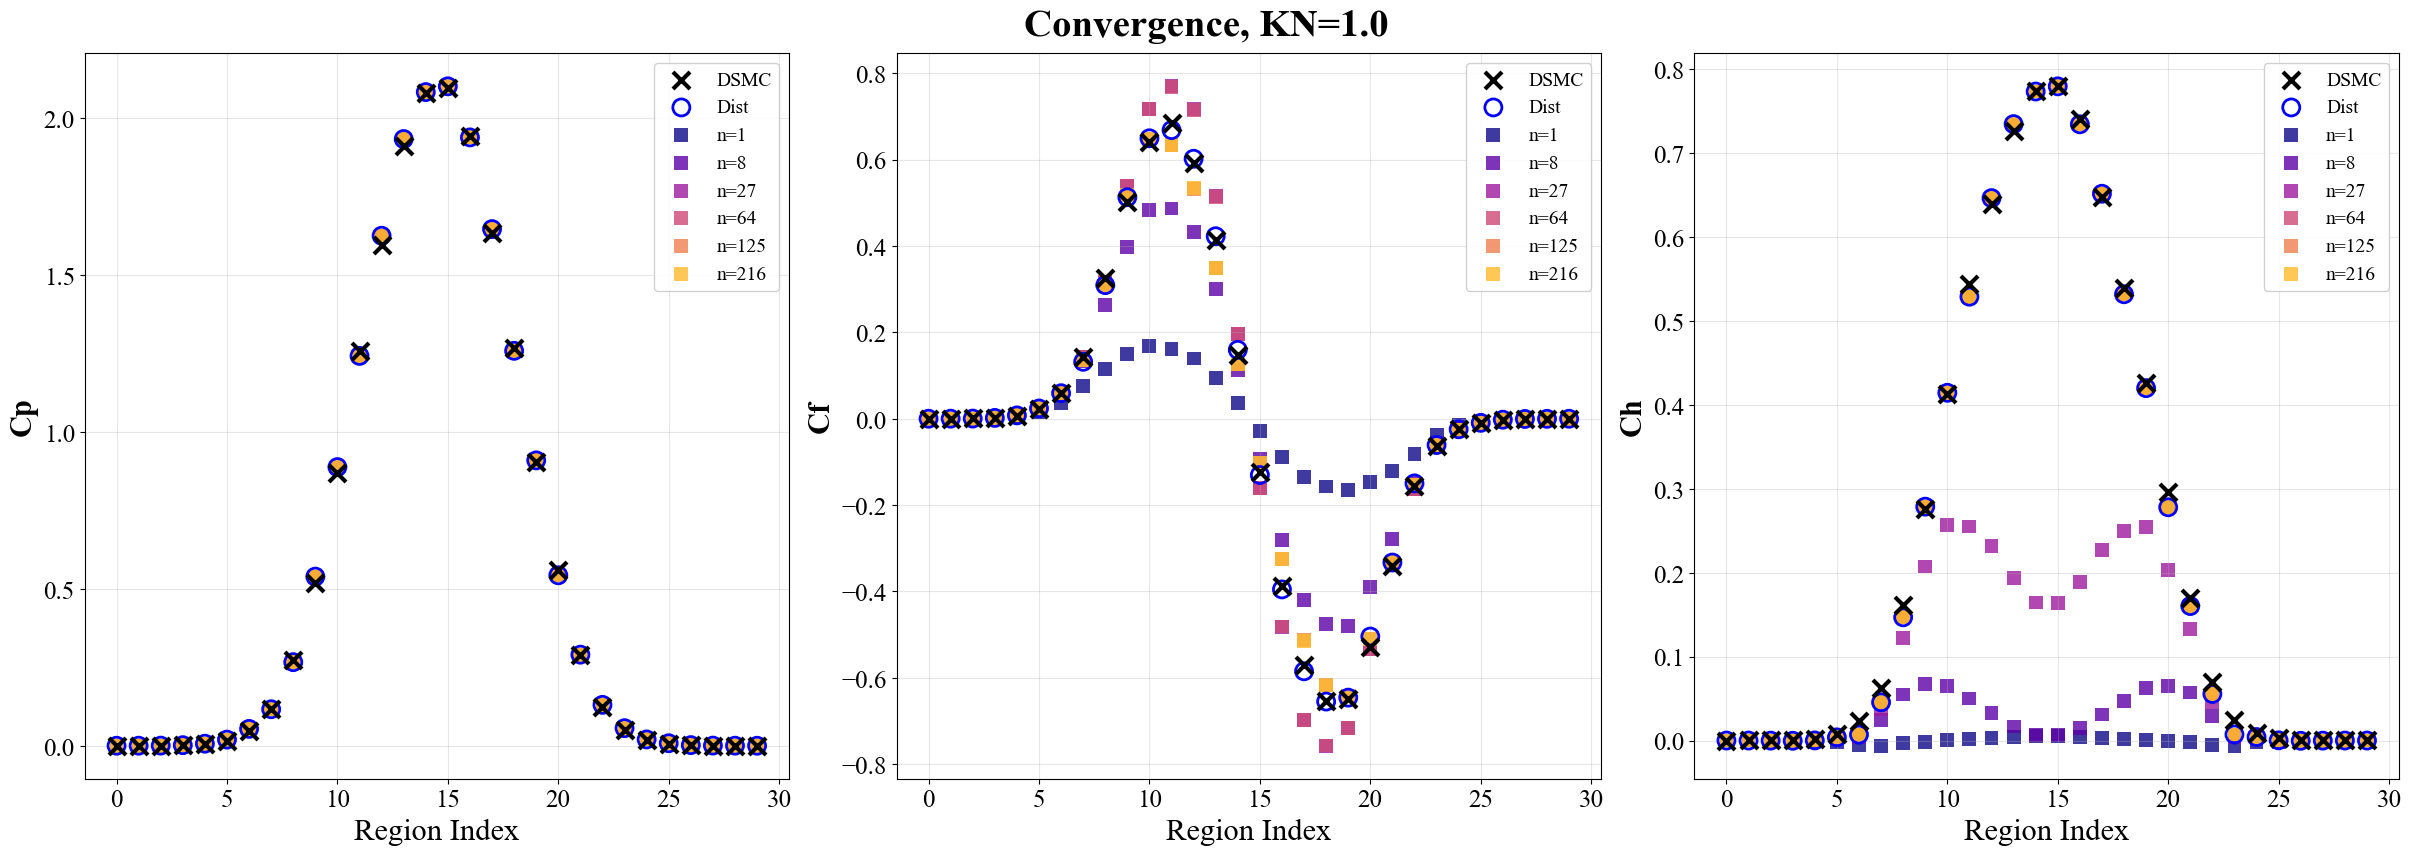

In [8]:
# KN_eq_0p01_path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p01_3D/0/"
# KN_eq_0p1_path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_0p1_3D/0/"
# KN_eq_1p0_path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_1p0_3D/0/"
# KN_eq_5p0_path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_5p0_3D/0/"
# KN_eq_10p0_path = "/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/KN_eq_10p0_3D/0/"
# metadata_path = Path("/Volumes/SherlockScratch/ARGON_CYLINDER_2D_DISTRIBUTIONS/validation_case_argon_circle/argon_circle_0_metadata.txt")

# print("Loading data...")
# # region_cache_0p01, region_df = load_run_data_3D(KN_eq_0p01_path, metadata_path)
# # print("Loaded KN=0.01 data")
# # region_cache_0p1, _ = load_run_data_3D(KN_eq_0p1_path, metadata_path)
# # print("Loaded KN=0.1 data")
# # region_cache_1p0, _ = load_run_data_3D(KN_eq_1p0_path, metadata_path)
# # print("Loaded KN=1.0 data")
# region_cache_5p0, region_df = load_run_data_3D(KN_eq_5p0_path, metadata_path)
# print("Loaded KN=5.0 data")
# region_cache_10p0, _ = load_run_data_3D(KN_eq_10p0_path, metadata_path)
# print("Loaded KN=10.0 data")

import pickle
# # To SAVE
# print("Saving data to pickle files...")
# with open('KN_eq_5p0_data.pkl', 'wb') as f:
#     pickle.dump((region_cache_5p0, region_df), f)
# print("Saved KN=5.0 data")

# with open('KN_eq_10p0_data.pkl', 'wb') as f:
#     pickle.dump((region_cache_10p0, region_df), f)
# print("Saved KN=10.0 data")

# with open('KN_eq_1p0_data.pkl', 'wb') as f:
#     pickle.dump((region_cache_1p0, region_df), f)
# print("Saved KN=1.0 data")

# try:
#     with open('KN_eq_0p1_data.pkl', 'rb') as f:
#         region_cache_0p1, region_df = pickle.load(f)
#     print("Loaded successfully")

#     # print("Sanity Check: Printing Data")
#     # print(region_cache_0p1[15]["data"])
#     # print("Sanity Check 2:")
#     # print(type(region_cache_0p1))
# except Exception as e:
#     print("Errooorrr:", e)

# To LOAD
# with open('KN_eq_0p01_data.pkl', 'rb') as f:
#     region_cache_0p01, region_df = pickle.load(f)

# with open('KN_eq_1p0_data.pkl', 'wb') as f:
#     pickle.dump((region_cache_1p0, region_df), f)

# with open('KN_eq_0p01_data.pkl', 'rb') as f:
#     region_cache_0p01, region_df = pickle.load(f)
# print("Kn = 0.01: Loaded successfully")

# with open('KN_eq_0p1_data.pkl', 'rb') as f:
#     region_cache_0p1, region_df = pickle.load(f)
# print("Kn = 0.1: Loaded successfully")

with open('KN_eq_1p0_data.pkl', 'rb') as f:
    region_cache_1p0, region_df = pickle.load(f)
print("Kn = 1.0: Loaded successfully")

# with open('KN_eq_5p0_data.pkl', 'rb') as f:
#     region_cache_5p0, region_df = pickle.load(f)
# print("Kn = 5.0: Loaded successfully")

# with open('KN_eq_10p0_data.pkl', 'rb') as f:
#     region_cache_10p0, region_df = pickle.load(f)
# print("Kn = 10.0: Loaded successfully")


import tqdm

N_TERMS = 6
moment_0p01_list = []
moment_0p1_list = []
moment_1p0_list = []
moment_5p0_list = []
moment_10p0_list = []
# moment_5p0_list_DEBUG = []
# moment_10p0_list_DEBUG = []

for n in tqdm.tqdm(range(1, N_TERMS + 1)):
    # moments_0p01 = calculate_and_compare_moments(region_cache_0p01, region_df, n_terms=n, verbose=False)
    # moments_0p1 = calculate_and_compare_moments(region_cache_0p1, region_df, n_terms=n, verbose=False)
    moments_1p0 = calculate_and_compare_moments(region_cache_1p0, region_df, n_terms=n, verbose=False)
    # moments_5p0 = calculate_and_compare_moments(region_cache_5p0, region_df, n_terms=n, verbose=False)
    # moments_10p0 = calculate_and_compare_moments(region_cache_10p0, region_df, n_terms=n, verbose=False)
    # moment_0p01_list.append(moments_0p01)
    # moment_0p1_list.append(moments_0p1)
    moment_1p0_list.append(moments_1p0)
    # moment_5p0_list.append(moments_5p0)
    # moment_10p0_list.append(moments_10p0)
    # moment_5p0_list_DEBUG.append(moments_5p0_DEBUG)
    # moment_10p0_list_DEBUG.append(moments_10p0_DEBUG)
#     # plot_cp_cf_ch(moments_0p01, m=6.36e-26, n_inf=4.247e20, u_inf=2634.1, title=f"Argon Cylinder, KN=0.01, n_terms={n}", all_in_one_plot=True)
#     # plot_cp_cf_ch(moments_0p1, m=6.36e-26, n_inf=4.247e19, u_inf=2634.1, title=f"KN=0.1, n_terms={n}", all_in_one_plot=True)  
#     # plot_cp_cf_ch(moments_1p0, m=6.36e-26, n_inf=4.247e18, u_inf=2634.1, title=f"KN=1.0, n_terms={n}", all_in_one_plot=True)

# plot_cp_cf_ch_all(moment_list, m=6.36e-26, n_inf=4.247e20, u_inf=2634.1, title=f"TEST", all_in_one_plot=False)
# plot_aerothermo_slides(moment_0p01_list, m=6.36e-26, n_inf=4.247e20, u_inf=2634.1, title="Convergence of Cp and Cf, KN=0.01", mode='dual')
# plot_aerothermo_slides(moment_0p1_list, m=6.36e-26, n_inf=4.247e19, u_inf=2634.1, title="Convergence of Cp and Cf, KN=0.1", mode='dual')
# plot_aerothermo_slides(moment_1p0_list, m=6.36e-26, n_inf=4.247e18, u_inf=2634.1, title="Convergence of Cp and Cf, KN=1.0", mode='dual')

# plot_aerothermo_slides(moment_0p01_list, m=6.36e-26, n_inf=4.247e20, u_inf=2634.1, title="Convergence, KN=0.01", mode='triple')
# plot_aerothermo_slides(moment_0p1_list, m=6.36e-26, n_inf=4.247e19, u_inf=2634.1, title="Convergence, KN=0.1", mode='triple')
plot_aerothermo_slides(moment_1p0_list, m=6.36e-26, n_inf=4.247e18, u_inf=2634.1, title="Convergence, KN=1.0", mode='triple')
# print(moment_5p0_list)
# print(moment_10p0_list)
# plot_aerothermo_slides(moment_5p0_list, m=6.36e-26, n_inf=8.494e17, u_inf=2634.1, title="Convergence, KN=5.0", mode='triple')
# plot_aerothermo_slides(moment_10p0_list, m=6.36e-26, n_inf=4.247e17, u_inf=2634.1, title="Convergence, KN=10.0", mode='triple')

In [9]:
# from scipy.special import comb
# from scipy.special import factorial
# from scipy.special import factorial2


# def Q_n_p(n, p, mean, std):
#     ''' Evaluate the pth moment of the nth order Hermite polynomial times a normal distribution with given mean and std. 
    
#     This is the integral of v^p * H_n((v - mean) / std) * (1/(sqrt(2*pi))) * exp(-0.5 * ((v - mean)/std)^2) dv from -inf to inf.
#     '''

#     if n > p:
#         return 0.0
#     else:
#         output = 0.0
#         for j in range(0, (p-n) + 1, 2):
#             if j == 0:
#                 output += comb(p-n,j) * std**j * mean**(p-n-j)
#             else:
#                 output += comb(p-n,j) * std**j * mean**(p-n-j) * factorial2(j-1, exact=True)

#         output *= std**(n+1) * (-1)**(2*n) * factorial(p) / factorial(p-n)
#         return output
    
# def Q_n_p_half(n, p, mean, std):
#     ''' Evaluate the pth moment of the nth order Hermite polynomial times a normal distribution with given mean and std. 
    
#     This is the integral of v^p * H_n((v - mean) / std) * (1/(sqrt(2*pi))) * exp(-0.5 * ((v - mean)/std)^2) dv from -inf to 0.
#     '''

#     if n > p:
#         return std**(p+1) * (-1)**(2*p+1)/np.sqrt(2*np.pi) * factorial(p) * hermite_polynomial(n-p-1,-mean/std, alpha=1) * np.exp(-0.5 * (mean/std)**2)
#     else:
#         output = 0.0
#         for j in range(0, (p-n) + 1):
#             if j == 0: # Special treatment for j=0
#                 output += 0.5*(-1)**(2*n)*std**(n+1)*factorial(p) / factorial(p-n)*comb(p-n,j) * std**j * mean**(p-n-j)
#             elif j % 2 == 1: # Odd j terms
#                 output += -1/np.sqrt(2*np.pi) * (-1)**(2*n) * std**(n+1)* factorial(p) / factorial(p-n) *comb(p-n,j) * std**j * mean**(p-n-j) * factorial2(j-1, exact=True)
#             else: # Even j terms
#                 output += 0.5*(-1)**(2*n)*std**(n+1)*factorial(p) / factorial(p-n)*comb(p-n,j) * std**j * mean**(p-n-j)*factorial2(j-1, exact=True)
#         return output



# def fast_momentum_flux_from_3D_hermite_fit(i, j, fit, n_i, m_spec = 6.36e-26):
#     """Calculate the (i,j)th momentum flux moment from the 3D Hermite fit coefficients."""
#     terms = fit['terms']
#     mean_T = fit['mean_T']
#     mean_N = fit['mean_N']
#     mean_Z = fit['mean_Z']
#     var_T = fit['var_T']
#     std_T = np.sqrt(var_T)
#     var_N = fit['var_N']
#     std_N = np.sqrt(var_N)
#     var_Z = fit['var_Z']
#     std_Z = np.sqrt(var_Z)

#     n_terms = terms.shape[0]
#     output = 0.0

#     if i == 0 and j == 0:
#         for k in range(n_terms):
#             for l in range(n_terms):
#                 for m in range(n_terms):
#                     Q_T = Q_n_p(k, 2, mean_T, std_T)
#                     Q_N = Q_n_p(l, 0, mean_N, std_N)
#                     Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
#                     output += terms[k, l, m] * Q_T * Q_N * Q_Z
#     elif i == 1 and j == 1:
#         for k in range(n_terms):
#             for l in range(n_terms):
#                 for m in range(n_terms):
#                     Q_T = Q_n_p(k, 0, mean_T, std_T)
#                     Q_N = Q_n_p(l, 2, mean_N, std_N)
#                     Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
#                     output += terms[k, l, m] * Q_T * Q_N * Q_Z
#     else:
#         for k in range(n_terms):
#             for l in range(n_terms):
#                 for m in range(n_terms):
#                     Q_T = Q_n_p(k, 1, mean_T, std_T)
#                     Q_N = Q_n_p_half(l, 1, mean_N, std_N)
#                     Q_Z = Q_n_p(m, 0, mean_Z, std_Z)
#                     output += terms[k, l, m] * Q_T * Q_N * Q_Z

#     return m_spec * n_i / (std_T * std_N * std_Z) * output
    
# def fast_heat_flux_from_3D_hermite_fit(fit, n_i, m_spec = 6.36e-26):
#     """Calculate the normal kinetic energy flux moment from the 3D Hermite fit coefficients."""
#     terms = fit['terms']
#     mean_T = fit['mean_T']
#     mean_N = fit['mean_N']
#     mean_Z = fit['mean_Z']
#     var_T = fit['var_T']
#     std_T = np.sqrt(var_T)
#     var_N = fit['var_N']
#     std_N = np.sqrt(var_N)
#     var_Z = fit['var_Z']
#     std_Z = np.sqrt(var_Z)

#     n_terms = terms.shape[0]
#     output = 0.0
#     for k in range(n_terms):
#         for l in range(n_terms):
#             for m in range(n_terms):
#                 # Term 1
#                 QT_1 = Q_n_p(k, 2, mean_T, std_T)
#                 QN_1 = Q_n_p(l, 1, mean_N, std_N)
#                 QZ_1 = Q_n_p(m, 0, mean_Z, std_Z)
#                 output += QT_1*QN_1*QZ_1

#                 # Term 2
#                 QT_2 = Q_n_p(k, 0, mean_T, std_T)
#                 QN_2 = Q_n_p(l, 3, mean_N, std_N)
#                 QZ_2 = Q_n_p(m, 0, mean_Z, std_Z)
#                 output += QT_2*QN_2*QZ_2

#                 # Term 3
#                 QT_3 = Q_n_p(k, 0, mean_T, std_T)
#                 QN_3 = Q_n_p(l, 1, mean_N, std_N)
#                 QZ_3 = Q_n_p(m, 2, mean_Z, std_Z)
#                 output += QT_3*QN_3*QZ_3

#     output *= 0.5 * m_spec * n_i / (std_T * std_N * std_Z)
#     return output

# # Q_n_p(4, 5, 5.2, 1)

# a = Q_n_p(5,2,-2.3,1)
# print(a)
# b = Q_n_p_half(5,2,-2.3,1)
# print(b)
